# OALTC KPI Tracking Framework- Data Infrastructure, Pipeline, Data Quality Control & Dashboard Reporting (A Demo)

*Prepared by: Zia U. Ahmed, Ph.D. · May 2026*






This notebook implements the KPI framework described in Sections 3 (Data Infrastructure & Pipeline Architecture)
and 4 (Dashboard & Reporting Design) loading staged BigQuery tables (dimension + raw data lake layers) via the **`google-cloud-bigquery`** client.

### Notebook structure

| Section | Content |
|---------|---------|
| **0** | Setup & dependencies |
| **3.1** | BigQuery data lake — facility dimension & raw fact tables |
| **3.2** | Data quality control — six-dimension framework |
| **3.3** | KPI calculation pipeline (SQL-equivalent in pandas) |
| **4.1** | Executive Strategic Scorecard |
| **4.2** | Program Performance Monitor (facility rankings) |
| **4.3** | Alert & Escalation System |


---
## Section 0: Setup & Dependencies

In [6]:
# ── Install dependencies (uncomment if needed) ──
# !pip install pandas numpy matplotlib seaborn plotly openpyxl google-cloud-bigquery pyarrow db-dtypes

import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from datetime import datetime, timedelta
from IPython.display import display, HTML
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Figures & CSV export directory (cloud: export OALTC_OUTPUT_DIR=/mnt/user-data/outputs)
OUTPUT_DIR = os.environ.get('OALTC_OUTPUT_DIR', os.path.join(os.getcwd(), 'outputs'))
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Global style ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Color palette ──
NAVY   = '#1F3864'
TEAL   = '#1A6B6B'
GOLD   = '#C07A00'
GREEN  = '#1A6B2A'
RED    = '#A32D2D'
LGRAY  = '#888888'
ALERT_COLOR  = '#FAD9D9'
WARN_COLOR   = '#FFF3CD'
OK_COLOR     = '#D6F0DC'

print("✅ Setup complete. All libraries loaded.")
print(f"   Pandas  {pd.__version__}  |  NumPy {np.__version__}  |  Plotly {__import__('plotly').__version__}")


✅ Setup complete. All libraries loaded.
   Pandas  2.3.3  |  NumPy 2.2.6  |  Plotly 6.6.0


---
## Section 3.1: BigQuery data lake (`google-cloud-bigquery`)

Three code cells load **`df_facilities`**, **`df_raw`** (discharge events), **`df_workforce`**, and **`df_complaints`** using the **[BigQuery Python client](https://cloud.google.com/python/docs/reference/bigquery/latest)**.

### Pipeline context (four layers)

1. **Ingestion** — facility submissions are already landed in the raw GCP dataset (here: `oaltc_raw`).
2. **Raw storage** — reads from fact-style tables (`nh_discharge_events`, `workforce_quarterly`, `complaint_investigations` by default).
3. **Transformation** — Section **3.2–3.3** apply QC rules and KPI logic in pandas (mirroring production SQL/views).
4. **Presentation** — Sections **4.x** consume the derived KPI mart and charts.

---

### Prerequisites

| Requirement | Notes |
|-------------|--------|
| Python packages | `pip install -r requirements.txt` in this repo (includes `google-cloud-bigquery`, `pyarrow`, `db-dtypes`). |
| **BigQuery API** enabled | [Enable BigQuery API](https://console.cloud.google.com/apis/library/bigquery.googleapis.com?project=oaltc-kpi-project-7748) for GCP project **`oaltc-kpi-project-7748`**. |
| **Credentials** | The kernel must see **ADC** or a **service account JSON** via env (see below). Logging into the web console alone does **not** authenticate Jupyter. |

| **Use BigQuery (not mock)** | 1) Run `bigquery/bootstrap_oaltc_lake.sql`. 2) `python scripts/hydrate_oaltc_lake_sample.py` (uses ADC / service account JSON; truncates then loads notebook-style sample data). 3) **Unset** `OALTC_USE_LOCAL_MOCK` (or set it to `0`). 4) **Restart** the Jupyter kernel and re-run Section 3.1. Optional: `export OALTC_BQ_NO_FALLBACK=1` so a missing table errors instead of falling back to mock. |


---

### Authenticating `bigquery.Client()` 

| Method | When to use | Steps |
|--------|--------------|-------|
| **Application Default Credentials** | Interactive development on your machine | In a terminal (same Linux user / account that launches Jupyter): `gcloud auth application-default login`, then `gcloud config set project oaltc-kpi-project-7748`. Optional: `export GOOGLE_CLOUD_PROJECT=oaltc-kpi-project-7748`. Full guide: [Set up ADC](https://cloud.google.com/docs/authentication/external/set-up-adc). |
| **Service account key** | CI, shared servers, locked-down laptops | Create a JSON key in IAM, grant BigQuery roles on the project/datasets, then `export GOOGLE_APPLICATION_CREDENTIALS=/absolute/path/key.json` and set `GOOGLE_CLOUD_PROJECT` (or `OALTC_BQ_PROJECT`). **Do not commit the key.** |

After changing env vars or running `gcloud auth`, **restart the Jupyter kernel** so the client picks them up.

**Useful console links (GCP project `oaltc-kpi-project-7748`):**

- [Google Cloud console](https://console.cloud.google.com/welcome/new?project=oaltc-kpi-project-7748)
- [BigQuery workspace](https://console.cloud.google.com/bigquery?project=oaltc-kpi-project-7748)
- [APIs & Services](https://console.cloud.google.com/apis/dashboard?project=oaltc-kpi-project-7748)

---

### Environment variables (all optional)

| Variable | Purpose |
|----------|---------|
| `GOOGLE_CLOUD_PROJECT` / `OALTC_BQ_PROJECT` | Explicit GCP project id (recommended if ADC does not imply a default project). |
| `GOOGLE_APPLICATION_CREDENTIALS` | Path to service account JSON (alternative to ADC). |
| `OALTC_BQ_DATASET_DIM` | Dimension dataset id (default `oaltc_dim`). |
| `OALTC_BQ_DATASET_RAW` | Raw / lake dataset id (default `oaltc_raw`). |
| `OALTC_BQ_TABLE_FACILITY` | Table for facility master (default `nh_facility_master`). |
| `OALTC_BQ_TABLE_DISCHARGE` | Discharge facts (default `nh_discharge_events`). |
| `OALTC_BQ_TABLE_WORKFORCE` | Workforce facts (default `workforce_quarterly`). |
| `OALTC_BQ_TABLE_COMPLAINTS` | Complaints (default `complaint_investigations`). |
| `OALTC_BQ_DISCHARGE_WHERE` | Extra SQL predicate for discharge query **without** the `WHERE` keyword, e.g. `report_year >= 2025`. |
| `OALTC_BQ_ROW_LIMIT` | Integer row cap appended to workload/complaints queries (**and** discharge when non-empty)—use only for quick tests (can skew KPI joins). |
| `OALTC_BQ_NO_FALLBACK` | `1` — do **not** fall back to local mock when the facility query fails with HTTP 404 (missing dataset/table). |
| `OALTC_USE_LOCAL_MOCK` | `1` / `true` — **force** in-process synthetic data (skips BigQuery even if configured). |
| `OALTC_BQ_STRICT` | `1` — if the BigQuery client cannot be imported, **raise** instead of auto mock-fallback (see below). |

If `google.cloud.bigquery` **fails to import** and **`OALTC_BQ_STRICT` is unset**, the notebook switches to the same **local mock** generator as above so cells still run offline.

**Seeing `404 … Dataset … oaltc_dim was not found`?** Provision the lake with **`bigquery/bootstrap_oaltc_lake.sql`**, then load data. For the same sample volumes the notebook mock uses—but stored in BigQuery—run **`python scripts/hydrate_oaltc_lake_sample.py`**. Until tables exist, if **`OALTC_USE_LOCAL_MOCK` is unset** the notebook will catch the missing table, set **`USE_LOCAL_MOCK`**, and continue offline with synthetic frames.



### Facility Master

This section loads the facility master list, which contains metadata for each nursing home
such as name, location, region, facility type, ownership, and other identifying columns.
The facility master serves as the dimension (reference) table for joining all other datasets
in the OALTC KPI analysis. It can be loaded from BigQuery (preferred for production and analysis),
or generated as a synthetic (mock) DataFrame for offline development and testing.

In [10]:
# ══════════════════════════════════════════════════════
# 3.1a Facility Master — BigQuery or Local Mock
# This code attempts to load the facility master dataframe from Google BigQuery by default,
# but it will fall back to using a locally-generated synthetic dataframe under certain conditions:
# - If the environment variable OALTC_USE_LOCAL_MOCK is set to 1/true/yes (case-insensitive),
#   always use a local synthetic DataFrame and NEVER contact BigQuery.
# - If the BigQuery client can't be imported, fall back to local.
# - If the BigQuery query fails due to a NotFound (table or dataset missing), and
#   OALTC_BQ_NO_FALLBACK is NOT set, fall back to local.

# Step 1: Parse environment variables to determine behavior and gather BigQuery configuration.
USE_LOCAL_MOCK = os.environ.get("OALTC_USE_LOCAL_MOCK", "").strip().lower() in ("1", "true", "yes")
NO_BQ_FALLBACK = os.environ.get("OALTC_BQ_NO_FALLBACK", "").strip().lower() in ("1", "true", "yes")

# Read table and dataset names from environment, falling back to defaults.
DATASET_DIM = os.environ.get("OALTC_BQ_DATASET_DIM", "oaltc_dim").strip()
DATASET_RAW = os.environ.get("OALTC_BQ_DATASET_RAW", "oaltc_raw").strip()
TBL_FACILITY = os.environ.get("OALTC_BQ_TABLE_FACILITY", "nh_facility_master").strip()
TBL_DISCHARGE = os.environ.get("OALTC_BQ_TABLE_DISCHARGE", "nh_discharge_events").strip()
TBL_WORKFORCE = os.environ.get("OALTC_BQ_TABLE_WORKFORCE", "workforce_quarterly").strip()
TBL_COMPLAINTS = os.environ.get("OALTC_BQ_TABLE_COMPLAINTS", "complaint_investigations").strip()

# Step 2: Helper to produce a synthetic facility master table in-memory as a DataFrame.
def _synthetic_facility_master_df() -> pd.DataFrame:
    regions = [
        "Western NY", "Central NY", "Capital Region",
        "NYC Metro", "Long Island", "North Country",
    ]
    facility_types = ["Skilled Nursing Facility", "Nursing Home", "CCRC"]
    ownership = ["Not-for-profit", "For-profit", "Government"]
    city_pools = {
        "Western NY": ["Buffalo", "Niagara Falls", "Lockport", "Batavia", "Olean"],
        "Central NY": ["Syracuse", "Utica", "Rome", "Auburn", "Cortland"],
        "Capital Region": ["Albany", "Troy", "Schenectady", "Saratoga Springs", "Glens Falls"],
        "NYC Metro": ["Bronx", "Brooklyn", "Queens", "Manhattan", "Staten Island"],
        "Long Island": ["Hempstead", "Babylon", "Huntington", "Oyster Bay", "Islip"],
        "North Country": ["Watertown", "Plattsburgh", "Ogdensburg", "Malone", "Canton"],
    }
    facilities = []
    for i in range(50):
        reg = regions[i % len(regions)]
        city = city_pools[reg][i % 5]
        facilities.append({
            "facility_id": f"NH-{i+1:03d}",
            "facility_name": f"{city} Care Center {i // 6 + 1}",
            "region": reg,
            "facility_type": np.random.choice(facility_types),
            "ownership": np.random.choice(ownership),
            "licensed_beds": int(np.random.randint(60, 200)),
            "county": city,
            "zip_code": str(f"1{np.random.randint(1000, 9999)}"),
        })
    return pd.DataFrame(facilities)

# Step 3: Helpers for mock BigQuery interface (needed so later code is compatible).
def _mock_bigquery_helpers():
    def bq_table_fqn(dataset: str, table: str) -> str:
        # Returns a fake "fully qualified name" for a table.
        return f"`local_mock.{dataset}.{table}`"

    def bq_query_to_df(sql: str) -> pd.DataFrame:
        # Raises an error if any code tries to query BigQuery when using the mock.
        raise RuntimeError("BigQuery queries are disabled in local mock mode.")

    return bq_table_fqn, bq_query_to_df

# Step 4: Activates the local mock, prints info, and provides mock DataFrame and helpers.
def _activate_local_facility_mock(lines: tuple) -> None:
    global USE_LOCAL_MOCK, df_facilities, bq_table_fqn, bq_query_to_df
    USE_LOCAL_MOCK = True
    for ln in lines:
        print(ln)
    df_facilities = _synthetic_facility_master_df()
    bq_table_fqn, bq_query_to_df = _mock_bigquery_helpers()

# Step 5: Main conditional logic
if USE_LOCAL_MOCK:
    # Always use local mock if flag is set.
    _activate_local_facility_mock(
        ("OALTC_USE_LOCAL_MOCK=1 — facility master generated in-process (no BigQuery).",)
    )
else:
    # Try to use BigQuery (requires google.cloud.bigquery library and credentials).
    try:
        from google.cloud import bigquery
    except ImportError:
        # If BigQuery library not installed, fall back to mock.
        _activate_local_facility_mock(
            (
                "❌ google.cloud.bigquery is not available in this environment.",
                "   Falling back to local mock mode for facility master data.",
            )
        )
    else:
        # Import exceptions for authentication and NotFound errors.
        from google.auth.exceptions import DefaultCredentialsError
        from google.api_core.exceptions import NotFound

        # Optionally pick a project (if specified in environment).
        BQ_PROJECT = (
            (os.environ.get("OALTC_BQ_PROJECT") or os.environ.get("GOOGLE_CLOUD_PROJECT") or "").strip()
            or None
        )

        # Try to initialize the BigQuery client using ADC or service account.
        try:
            bq_client = bigquery.Client(project=BQ_PROJECT) if BQ_PROJECT else bigquery.Client()
        except DefaultCredentialsError as err:
            # If credentials missing, print instructions and fail.
            _example = "oaltc-kpi-project-7748"
            _pid = BQ_PROJECT or os.environ.get("GOOGLE_CLOUD_PROJECT") or _example
            raise RuntimeError(
                "BigQuery: Application Default Credentials were not found.\n\n"
                "Do this on the machine that runs Jupyter:\n"
                "  1) gcloud auth application-default login\n"
                f"  2) gcloud config set project {_example}\n"
                f"  3) export GOOGLE_CLOUD_PROJECT={_example}\n\n"
                "Or use a service account: export GOOGLE_APPLICATION_CREDENTIALS=/path/key.json\n\n"
                f"Enable BigQuery API: https://console.cloud.google.com/apis/library/bigquery.googleapis.com?project={_pid}\n"
                f"Open BigQuery: https://console.cloud.google.com/bigquery?project={_pid}\n"
                "ADC guide: https://cloud.google.com/docs/authentication/external/set-up-adc\n\n"
                "Use offline data instead: export OALTC_USE_LOCAL_MOCK=1\n\n"
                f"Underlying error: {err}"
            ) from err

        # Helper to generate BigQuery table reference (with project if specified).
        def bq_table_fqn(dataset: str, table: str) -> str:
            if BQ_PROJECT:
                return f"`{BQ_PROJECT}.{dataset}.{table}`"
            return f"`{dataset}.{table}`"

        # Helper to run SQL using the initialized BigQuery client.
        def bq_query_to_df(sql: str) -> pd.DataFrame:
            return bq_client.query(sql).result().to_dataframe()

        # Actual SQL to load facility master data from the configured table.
        _sql_facility = f"""
SELECT
    facility_id,
    facility_name,
    region,
    facility_type,
    ownership,
    licensed_beds,
    county,
    CAST(zip_code AS STRING) AS zip_code
FROM {bq_table_fqn(DATASET_DIM, TBL_FACILITY)}
"""
        try:
            df_facilities = bq_query_to_df(_sql_facility)
        except NotFound as exc:
            # If table/dataset missing, either raise or fall back to local, depending on flag.
            if NO_BQ_FALLBACK:
                raise
            fq = bq_table_fqn(DATASET_DIM, TBL_FACILITY).strip("`")
            _activate_local_facility_mock(
                (
                    "⚠️ BigQuery facility query returned 404 (dataset or table missing).",
                    f"   Expected roughly: `{fq}`",
                    "   Create the dataset/table in GCP or set OALTC_USE_LOCAL_MOCK=1; use OALTC_BQ_NO_FALLBACK=1 to force failure.",
                    "   Bootstrap empty datasets/tables: bigquery/bootstrap_oaltc_lake.sql",
                    f"   Underlying message: {exc}",
                )
            )
        else:
            # If BigQuery query successful: print summary to notebook.
            print(
                f"Facility master via BigQuery: {df_facilities.shape[0]} facilities across "
                f"{df_facilities.region.nunique()} regions"
            )
            print(
                f"   Source: {bq_table_fqn(DATASET_DIM, TBL_FACILITY)}  |  client project: {bq_client.project}"
            )

# Final line: print summary and show a sample of the facilities DataFrame (from BigQuery or mock).
print(f"Facility master rows: {df_facilities.shape[0]} across {df_facilities.region.nunique()} regions")
display(df_facilities.head(8))


⚠️ BigQuery facility query returned 404 (dataset or table missing).
   Expected roughly: `oaltc_dim.nh_facility_master`
   Create the dataset/table in GCP or set OALTC_USE_LOCAL_MOCK=1; use OALTC_BQ_NO_FALLBACK=1 to force failure.
   Bootstrap empty datasets/tables: bigquery/bootstrap_oaltc_lake.sql
   Underlying message: 404 Not found: Dataset oaltc-kpi-project-7748:oaltc_dim was not found in location US; reason: notFound, message: Not found: Dataset oaltc-kpi-project-7748:oaltc_dim was not found in location US

Location: US
Job ID: 2ba943bd-4571-41bd-9a40-52bdce150437

Facility master rows: 50 across 6 regions


,facility_id,facility_name,region,facility_type,ownership,licensed_beds,county,zip_code
0,NH-001,Buffalo Care Center 1,Western NY,Skilled Nursing Facility,Not-for-profit,158,Buffalo,11886
1,NH-002,Utica Care Center 1,Central NY,CCRC,Not-for-profit,122,Utica,15092
2,NH-003,Schenectady Care Center 1,Capital Region,CCRC,For-profit,178,Schenectady,11340
3,NH-004,Manhattan Care Center 1,NYC Metro,CCRC,Not-for-profit,100,Manhattan,14845
4,NH-005,Islip Care Center 1,Long Island,Nursing Home,Government,173,Islip,12142
5,NH-006,Watertown Care Center 1,North Country,Skilled Nursing Facility,For-profit,112,Watertown,14688
6,NH-007,Niagara Falls Care Center 2,Western NY,Skilled Nursing Facility,For-profit,167,Niagara Falls,19083
7,NH-008,Rome Care Center 2,Central NY,Skilled Nursing Facility,For-profit,96,Rome,13217


### Raw Discharge Events

This section initiates the processing of raw discharge event data for each facility. 
It prepares the dataset used in subsequent analyses—either loading it from BigQuery or, if a mock environment is used, generating simulated event records.

The discharge events dataset contains details such as admission and discharge dates, patient outcomes, monthly reporting structure, and data quality flags.

This information is foundational for computing quality metrics and tracking readmission and adverse events across the region.

In [11]:
# ══════════════════════════════════════════════════════
# 3.1b  Raw discharge events — BigQuery or local mock
#        BigQuery default: `oaltc_raw.nh_discharge_events`
# ══════════════════════════════════════════════════════
# gcloud config set project oaltc-kpi-project-7748
# export GOOGLE_CLOUD_PROJECT=oaltc-kpi-project-7748

if USE_LOCAL_MOCK:
    print("Simulating discharge events (local mock)...")

    def simulate_discharge_events(df_facilities, n_months=13):
        records = []
        end_date = datetime(2026, 5, 1)
        start_date = end_date - timedelta(days=30 * n_months)
        for _, fac in df_facilities.iterrows():
            base_readmit = np.random.uniform(0.10, 0.28)
            base_ulcer = np.random.uniform(0.001, 0.007)
            base_adl_score = np.random.uniform(6, 18)
            monthly_discharges = int(np.random.randint(15, 60))
            current = start_date
            while current < end_date:
                for _ in range(monthly_discharges):
                    admit_date = current - timedelta(days=int(np.random.randint(5, 90)))
                    discharge_date = current + timedelta(days=int(np.random.randint(0, 28)))
                    readmitted = np.random.random() < base_readmit
                    dq_issue = np.random.random() < 0.05
                    records.append({
                        "facility_id": fac["facility_id"],
                        "resident_id": f"RES-{np.random.randint(100000, 999999)}",
                        "admit_date": admit_date.strftime("%Y-%m-%d") if not (dq_issue and np.random.random() < 0.3) else "INVALID",
                        "discharge_date": discharge_date.strftime("%Y-%m-%d"),
                        "report_year": current.year,
                        "report_month": current.month,
                        "readmitted_30d": readmitted,
                        "new_pressure_ulcer": np.random.random() < base_ulcer,
                        "adl_score": round(base_adl_score + np.random.normal(0, 2), 1) if not (dq_issue and np.random.random() < 0.2) else np.nan,
                        "outcome_code": np.random.choice(["01", "02", "03", "04", "05"]) if not (dq_issue and np.random.random() < 0.15) else None,
                        "payer_type": np.random.choice(["Medicaid", "Medicare", "Private", "Other"], p=[0.55, 0.25, 0.15, 0.05]),
                        "race_ethnicity": np.random.choice(["White", "Black", "Hispanic", "Asian", "Other"], p=[0.55, 0.20, 0.15, 0.06, 0.04]),
                        "data_quality_flag": "FAIL" if dq_issue else "PASS",
                        "submission_date": (current + timedelta(days=int(np.random.randint(1, 15)))).strftime("%Y-%m-%d"),
                    })
                current = (current.replace(day=1) + timedelta(days=32)).replace(day=1)
        return pd.DataFrame(records)

    df_raw = simulate_discharge_events(df_facilities)
    n_pass = int((df_raw.data_quality_flag == "PASS").sum())
    n_fail = int((df_raw.data_quality_flag == "FAIL").sum())
else:
    _discharge_where = os.environ.get("OALTC_BQ_DISCHARGE_WHERE", "").strip()
    _row_limit = os.environ.get("OALTC_BQ_ROW_LIMIT", "").strip()

    _sql_discharge = f"""
SELECT
    facility_id,
    CAST(resident_id AS STRING) AS resident_id,
    FORMAT_DATE('%Y-%m-%d', SAFE_CAST(admit_date AS DATE)) AS admit_date,
    FORMAT_DATE('%Y-%m-%d', SAFE_CAST(discharge_date AS DATE)) AS discharge_date,
    report_year,
    report_month,
    readmitted_30d,
    new_pressure_ulcer,
    adl_score,
    CAST(outcome_code AS STRING) AS outcome_code,
    payer_type,
    race_ethnicity,
    data_quality_flag,
    FORMAT_DATE('%Y-%m-%d', SAFE_CAST(submission_date AS DATE)) AS submission_date
FROM {bq_table_fqn(DATASET_RAW, TBL_DISCHARGE)}
"""

    if _discharge_where:
        _sql_discharge += f"\nWHERE ({_discharge_where})"

    if _row_limit.isdigit():
        _sql_discharge += f"\nLIMIT {int(_row_limit)}"

    print("Loading discharge events from BigQuery...")
    df_raw = bq_query_to_df(_sql_discharge)
    n_pass = int((df_raw.data_quality_flag == "PASS").sum())
    n_fail = int((df_raw.data_quality_flag == "FAIL").sum())

print(f"✅ Raw data lake: {len(df_raw):,} discharge event records")
yr_lo = df_raw.report_year.min()
mo_lo = int(df_raw.loc[df_raw.report_year == yr_lo, "report_month"].min())
yr_hi = df_raw.report_year.max()
mo_hi = int(df_raw.loc[df_raw.report_year == yr_hi, "report_month"].max())
print(f"   Date range  : {yr_lo}-{mo_lo:02d}  →  {yr_hi}-{mo_hi:02d}")
print(f"   Facilities  : {df_raw.facility_id.nunique()}")
print(f"   PASS records: {n_pass:,}  |  FAIL records: {n_fail:,}")



Simulating discharge events (local mock)...
✅ Raw data lake: 26,468 discharge event records
   Date range  : 2025-04  →  2026-04
   Facilities  : 50
   PASS records: 25,162  |  FAIL records: 1,306


### Workforce & complaints

- This section focuses on the processing and analysis of workforce and complaints data for long-term care facilities.
- Workforce data includes staff headcounts, turnover rates, RN hours, and vacancy rates across recent quarters, providing insight into staffing stability and sufficiency.
- Complaints data summarizes the frequency, types, and resolution timeliness of complaints filed against facilities.
- The analysis in this section uses either a local mock data generator or queries live data from BigQuery, depending on the execution environment.

In [12]:
# ══════════════════════════════════════════════════════
# 3.1c  Workforce & complaints — BigQuery or local mock
# ══════════════════════════════════════════════════════

if USE_LOCAL_MOCK:

    def simulate_workforce(df_facilities, n_quarters=6):
        records = []
        quarters = [(2025, 1), (2025, 2), (2025, 3), (2025, 4), (2026, 1), (2026, 2)][:n_quarters]
        for _, fac in df_facilities.iterrows():
            base_turnover = np.random.uniform(0.15, 0.65)
            for yr, qtr in quarters:
                avg_headcount = np.random.randint(40, 180)
                separations = int(avg_headcount * base_turnover / 4 * np.random.uniform(0.7, 1.3))
                dq_issue = np.random.random() < 0.04
                records.append({
                    "facility_id": fac["facility_id"],
                    "report_year": yr,
                    "report_quarter": qtr,
                    "avg_staff_headcount": avg_headcount if not dq_issue else np.nan,
                    "staff_separations": separations,
                    "rn_hours_per_day": round(np.random.uniform(0.3, 1.8), 2),
                    "vacancy_rate_pct": round(np.random.uniform(2, 25), 1),
                    "data_quality_flag": "FAIL" if dq_issue else "PASS",
                })
        return pd.DataFrame(records)

    def simulate_complaints(df_facilities, n_months=13):
        records = []
        for _, fac in df_facilities.iterrows():
            base_rate = np.random.uniform(0.6, 1.5)
            for month_offset in range(n_months):
                dt = datetime(2025, 4, 1) + timedelta(days=30 * month_offset)
                n = max(0, int(np.random.poisson(base_rate)))
                for _ in range(n):
                    resolved_days = int(
                        np.random.choice([np.random.randint(1, 10), np.random.randint(10, 30)], p=[0.78, 0.22])
                    )
                    records.append({
                        "facility_id": fac["facility_id"],
                        "report_year": dt.year,
                        "report_month": dt.month,
                        "complaint_id": f"CMP-{np.random.randint(100000, 999999)}",
                        "days_to_resolution": resolved_days,
                        "complaint_type": np.random.choice(
                            ["Quality of Care", "Abuse/Neglect", "Environment", "Staffing", "Other"]
                        ),
                        "data_quality_flag": "PASS",
                    })
        return pd.DataFrame(records)

    print("Simulating workforce (local mock)...")
    df_workforce = simulate_workforce(df_facilities)
    print(f"✅ Workforce data lake: {len(df_workforce):,} quarterly records")

    print("Simulating complaints (local mock)...")
    df_complaints = simulate_complaints(df_facilities)
    print(f"✅ Complaint investigations: {len(df_complaints):,} records")

else:
    _row_limit = os.environ.get("OALTC_BQ_ROW_LIMIT", "").strip()
    _limit_clause = f"\nLIMIT {int(_row_limit)}" if _row_limit.isdigit() else ""

    _sql_workforce = f"""
SELECT
    facility_id,
    report_year,
    report_quarter,
    avg_staff_headcount,
    staff_separations,
    rn_hours_per_day,
    vacancy_rate_pct,
    data_quality_flag
FROM {bq_table_fqn(DATASET_RAW, TBL_WORKFORCE)}
{_limit_clause}
"""

    _sql_complaints = f"""
SELECT
    facility_id,
    report_year,
    report_month,
    CAST(complaint_id AS STRING) AS complaint_id,
    days_to_resolution,
    complaint_type,
    data_quality_flag
FROM {bq_table_fqn(DATASET_RAW, TBL_COMPLAINTS)}
{_limit_clause}
"""

    print("Loading workforce quarterly from BigQuery...")
    df_workforce = bq_query_to_df(_sql_workforce)
    print(f"✅ Workforce data lake: {len(df_workforce):,} quarterly records")

    print("Loading complaint investigations from BigQuery...")
    df_complaints = bq_query_to_df(_sql_complaints)
    print(f"✅ Complaint investigations: {len(df_complaints):,} records")

print("\nLayer 1 (Raw Data Lake) — all tables ready.")



Simulating workforce (local mock)...
✅ Workforce data lake: 300 quarterly records
Simulating complaints (local mock)...
✅ Complaint investigations: 693 records

Layer 1 (Raw Data Lake) — all tables ready.


---
## Section 3.2: Data Quality Control — Six-Dimension Framework

Each record passing through the pipeline is evaluated on six quality dimensions.
Failed records are flagged, logged, and excluded from KPI calculations.
Submitters receive automated notifications for records below threshold.


In [13]:
# ══════════════════════════════════════════════════════
# 3.2a  Six-Dimension DQ Assessment
# ══════════════════════════════════════════════════════

def assess_data_quality(df_raw):
    """
    Apply all six DQ dimensions and return a record-level quality report.

    Dimensions
    ----------
    1. Completeness  — required fields are non-null
    2. Validity      — values within defined ranges / formats
    3. Timeliness    — submission within expected window
    4. Consistency   — cross-field logical checks
    5. Accuracy      — statistical outlier detection (z-score)
    6. Uniqueness    — no duplicate composite keys
    """
    df = df_raw.copy()

    # 1. Completeness — required fields
    required_fields = ['facility_id','resident_id','discharge_date','report_year','report_month','outcome_code']
    df['dq_completeness'] = df[required_fields].notna().all(axis=1) &                             (df[required_fields].astype(str) != 'INVALID').all(axis=1)

    # 2. Validity — value range / format checks
    df['dq_validity'] = (
        df['report_year'].between(2020, 2027) &
        df['report_month'].between(1, 12) &
        df['outcome_code'].isin(['01','02','03','04','05', None, np.nan]) &
        df['adl_score'].between(0, 28, inclusive='both').fillna(True)
    )

    # 3. Timeliness — submission within 14 days of report period close
    df['submission_date_dt'] = pd.to_datetime(df['submission_date'], errors='coerce')
    report_close = pd.to_datetime(df[['report_year','report_month']].assign(day=28).rename(
        columns={'report_year':'year','report_month':'month'}))
    days_late = (df['submission_date_dt'] - report_close).dt.days.fillna(99)
    df['dq_timeliness'] = days_late <= 14

    # 4. Consistency — admit_date must precede discharge_date
    df['admit_date_dt']     = pd.to_datetime(df['admit_date'],    errors='coerce')
    df['discharge_date_dt'] = pd.to_datetime(df['discharge_date'], errors='coerce')
    df['dq_consistency'] = (
        df['admit_date_dt'].notna() &
        df['discharge_date_dt'].notna() &
        (df['admit_date_dt'] <= df['discharge_date_dt'])
    )

    # 5. Accuracy — z-score outlier on ADL score per facility
    fac_stats = df.groupby('facility_id')['adl_score'].agg(['mean','std']).rename(
        columns={'mean':'adl_mean','std':'adl_std'})
    df = df.merge(fac_stats, on='facility_id', how='left')
    z = (df['adl_score'] - df['adl_mean']) / df['adl_std'].replace(0, np.nan)
    df['dq_accuracy'] = (z.abs() <= 3).fillna(True)

    # 6. Uniqueness — composite key: facility_id + resident_id + discharge_date
    df['composite_key']  = df['facility_id'] + '_' + df['resident_id'].astype(str) + '_' + df['discharge_date'].astype(str)
    df['dq_uniqueness']  = ~df['composite_key'].duplicated(keep='first')

    # ── Composite pass/fail ──
    dq_cols = ['dq_completeness','dq_validity','dq_timeliness','dq_consistency','dq_accuracy','dq_uniqueness']
    df['dq_all_pass'] = df[dq_cols].all(axis=1)

    # ── Dimension-level summary ──
    dim_summary = pd.DataFrame({
        'Dimension':  ['Completeness','Validity','Timeliness','Consistency','Accuracy','Uniqueness'],
        'Pass_Count': [df[c].sum() for c in dq_cols],
        'Total':      len(df),
    })
    dim_summary['Fail_Count'] = dim_summary['Total'] - dim_summary['Pass_Count']
    dim_summary['Pass_Rate']  = (dim_summary['Pass_Count'] / dim_summary['Total'] * 100).round(2)

    return df, dim_summary

df_raw_assessed, dq_summary = assess_data_quality(df_raw)
print("Data Quality Assessment Complete")
print("=" * 50)
print(dq_summary.to_string(index=False))
print(f"\nOverall pass rate: {df_raw_assessed['dq_all_pass'].mean()*100:.1f}%")
print(f"Records passing all 6 checks: {df_raw_assessed['dq_all_pass'].sum():,} / {len(df_raw_assessed):,}")

Data Quality Assessment Complete
   Dimension  Pass_Count  Total  Fail_Count  Pass_Rate
Completeness       26269  26468         199      99.25
    Validity       26193  26468         275      98.96
  Timeliness       26468  26468           0     100.00
 Consistency       26073  26468         395      98.51
    Accuracy       26129  26468         339      98.72
  Uniqueness       26468  26468           0     100.00

Overall pass rate: 97.1%
Records passing all 6 checks: 25,709 / 26,468


The above table summarizes the data quality check results across six dimensions: Completeness, Validity, Timeliness, Consistency, Accuracy, and Uniqueness.
- For each dimension, it displays the number of records passing and failing the check, as well as the pass rate (percentage of records passing).
- These metrics provide a quantitative overview of data quality issues in the source dataset and highlight where further data cleaning or investigation may be needed.
- The final lines report the overall pass rate (records passing all six checks) and the absolute number of fully clean records.

### Data Quality Visualization

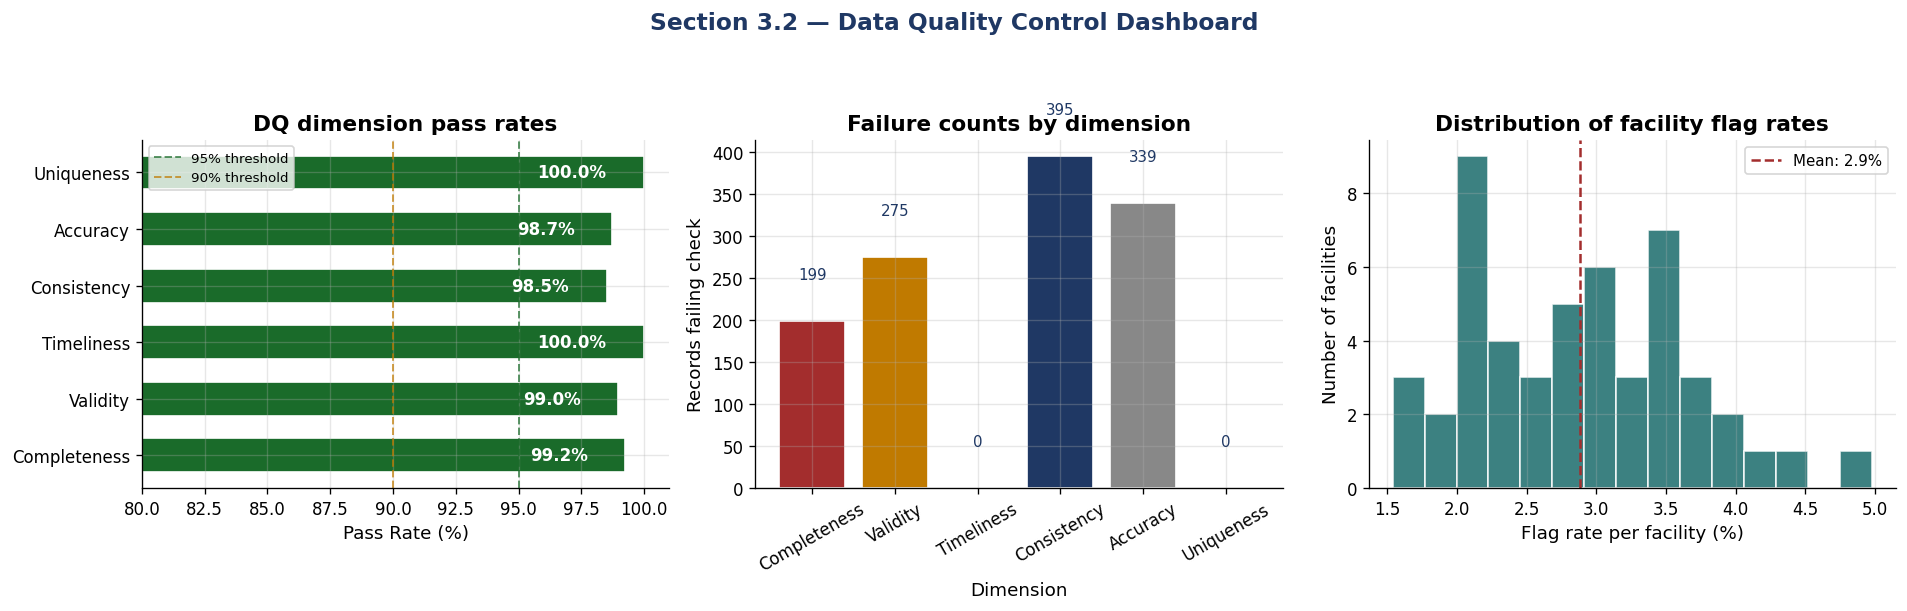

In [22]:
# ══════════════════════════════════════════════════════
# 3.2b  Data Quality Visualizations
# ══════════════════════════════════════════════════════

import os

# For Jupyter: always show figures inline. Use this cell to enforce.
%matplotlib inline

# In some environments, you may need to force a close/show cycle for mpl
import matplotlib
matplotlib.use('Agg' if os.environ.get("OALTC_USE_LOCAL_MOCK") else 'module://matplotlib_inline.backend_inline')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 3.2 — Data Quality Control Dashboard', fontsize=14, fontweight='bold', color=NAVY, y=1.01)

# ── Plot 1: Six-dimension pass rates ──
ax = axes[0]
colors = [GREEN if r >= 95 else GOLD if r >= 90 else RED for r in dq_summary['Pass_Rate']]
bars   = ax.barh(dq_summary['Dimension'], dq_summary['Pass_Rate'], color=colors, height=0.6, edgecolor='white')
ax.axvline(95, color=GREEN, linestyle='--', linewidth=1.2, label='95% threshold', alpha=0.7)
ax.axvline(90, color=GOLD,  linestyle='--', linewidth=1.2, label='90% threshold', alpha=0.7)
for bar, pct in zip(bars, dq_summary['Pass_Rate']):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', ha='right', fontsize=10, color='white', fontweight='bold')
ax.set_xlabel('Pass Rate (%)')
ax.set_title('DQ dimension pass rates', fontweight='bold')
ax.set_xlim(80, 101)
ax.legend(fontsize=8)

# ── Plot 2: Fail counts by dimension ──
ax = axes[1]
ax.bar(dq_summary['Dimension'], dq_summary['Fail_Count'], color=[RED, GOLD, GOLD, NAVY, LGRAY, GREEN], edgecolor='white')
ax.set_xlabel('Dimension')
ax.set_ylabel('Records failing check')
ax.set_title('Failure counts by dimension', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(dq_summary['Fail_Count']):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9, color=NAVY)

# ── Plot 3: Facility-level DQ flag rate distribution ──
ax = axes[2]
fac_dq = df_raw_assessed.groupby('facility_id').apply(
    lambda x: (1 - x['dq_all_pass'].mean()) * 100).reset_index(name='flag_rate_pct')

# Check for any NaN or infinite values that might prevent plotting
fac_dq_clean = fac_dq[fac_dq['flag_rate_pct'].notnull() & fac_dq['flag_rate_pct'].apply(np.isfinite)]

# Defensive: if there's nothing to show, clearly indicate
if fac_dq_clean.empty:
    ax.text(0.5, 0.5, "No data to display", ha='center', va='center', fontsize=13, color=RED, transform=ax.transAxes)
    ax.set_axis_off()
else:
    ax.hist(fac_dq_clean['flag_rate_pct'], bins=15, color=TEAL, edgecolor='white', alpha=0.85)
    ax.axvline(fac_dq_clean['flag_rate_pct'].mean(), color=RED, linestyle='--', linewidth=1.5,
               label=f"Mean: {fac_dq_clean['flag_rate_pct'].mean():.1f}%")
    ax.set_xlabel('Flag rate per facility (%)')
    ax.set_ylabel('Number of facilities')
    ax.set_title('Distribution of facility flag rates', fontweight='bold')
    ax.legend(fontsize=9)

fig.tight_layout(rect=[0, 0, 1, 0.97])

# Only show the figure once
plt.show()
plt.close(fig)

# Also save as PNG regardless
fig.savefig("section_3_2_data_quality_dashboard.png", bbox_inches="tight")

 The above figure provides a comprehensive summary of data quality (DQ) metrics across multiple dimensions for all facility records.  
 - **Left panel:** Bar plot showing the percentage of records passing DQ checks for each core data quality dimension (completeness, validity, timeliness, consistency, uniqueness, and overall DQ). Higher percentages indicate better data quality for that dimension.
 - **Middle panel:** Bar plot showing the raw number of records failing each DQ check, highlighting which dimensions most often contribute to data quality issues.
 - **Right panel:** Histogram illustrating the distribution of facility-level flag (failure) rates across all records. This shows, for each facility, the proportion of records with at least one DQ failure. A vertical dashed line marks the mean facility flag rate.  
 The figure helps quickly identify systemic DQ issues and outlier facilities needing review or remediation.

### Data Quality Table

In [7]:
# ── Facility DQ report table ──
fac_dq_report = df_raw_assessed.groupby('facility_id').agg(
    total_records   = ('dq_all_pass', 'count'),
    passed_records  = ('dq_all_pass', 'sum'),
    completeness_pct= ('dq_completeness', lambda x: round(x.mean()*100, 1)),
    validity_pct    = ('dq_validity',     lambda x: round(x.mean()*100, 1)),
    timeliness_pct  = ('dq_timeliness',   lambda x: round(x.mean()*100, 1)),
    consistency_pct = ('dq_consistency',  lambda x: round(x.mean()*100, 1)),
    uniqueness_pct  = ('dq_uniqueness',   lambda x: round(x.mean()*100, 1)),
).reset_index()
fac_dq_report['overall_pass_pct'] = (fac_dq_report['passed_records'] / fac_dq_report['total_records'] * 100).round(1)
fac_dq_report['flag_rate_pct']    = (100 - fac_dq_report['overall_pass_pct']).round(1)
fac_dq_report['dq_status'] = fac_dq_report['overall_pass_pct'].apply(
    lambda x: 'PASS' if x >= 95 else ('REVIEW' if x >= 88 else 'FAIL'))

fac_dq_report = fac_dq_report.merge(df_facilities[['facility_id','facility_name','region']], on='facility_id')
flagged = fac_dq_report[fac_dq_report['flag_rate_pct'] > 5].sort_values('flag_rate_pct', ascending=False)

print(f"Facilities with flag rate > 5%: {len(flagged)}")
display(flagged[['facility_id','facility_name','region','total_records','flag_rate_pct',
                 'completeness_pct','validity_pct','timeliness_pct','dq_status']].head(10))

# ── Layer 2 clean output (passes all DQ checks) ──
df_clean = df_raw_assessed[df_raw_assessed['dq_all_pass']].copy()
print(f"\n✅ Layer 2 → Layer 3: {len(df_clean):,} clean records passed to transformation layer")

Facilities with flag rate > 5%: 1


,facility_id,facility_name,region,total_records,flag_rate_pct,completeness_pct,validity_pct,timeliness_pct,dq_status
35,NH-036,Watertown Care Center 6,North Country,624,5.1,98.2,98.7,100.0,REVIEW



✅ Layer 2 → Layer 3: 24,658 clean records passed to transformation layer


---
## Section 3.3: KPI Calculation Pipeline (SQL-equivalent in pandas)

Each function below mirrors a **BigQuery SQL view** from the framework.
The same logic, column names, threshold rules, and performance status labels are used.
In production, these would be `CREATE OR REPLACE VIEW` statements executed in BigQuery.

**Prerequisite:** **`df_clean`** comes from Section **3.2** (facility DQ report cell). If you only skipped that cell, the first KPI code cell recomputes `df_clean` from **`df_raw_assessed`** automatically.


### KPI 1:  30-Day Hospital Readmission Rate

This section calculates the first Key Performance Indicator (KPI): the 30-day hospital readmission rate for each facility by month.

- It replicates the logic of the BigQuery SQL view `oaltc_kpi.readmission_rate_monthly`, but executes it using pandas.
- For each facility and month, it counts how many discharged residents were readmitted within 30 days (`readmitted_30d`).
- The rate is then calculated as the percentage of readmissions out of total discharges for that period.
- Facilities are categorized based on their rates: 
    - "ALERT" if the rate is above 22%,
    - "WARNING" if between 18–22%,
    - "ON TARGET" if 18% or below.
- The resulting table is used for performance management and reporting.

In [26]:
# ══════════════════════════════════════════════════════
# 3.3a  KPI 1 — 30-Day Hospital Readmission Rate
#        BigQuery view: oaltc_kpi.readmission_rate_monthly
# ══════════════════════════════════════════════════════
# SQL equivalent:
#   SELECT facility_id, report_year, report_month,
#          COUNT(CASE WHEN readmitted_30d THEN 1 END) / COUNT(*) * 100 AS rate
#   FROM oaltc_raw.nh_discharge_events
#   WHERE data_quality_flag = 'PASS'
#   GROUP BY 1, 2, 3

# Section 3.2 usually defines `df_clean` in the Facility DQ report cell; rebuild if skipped.
if "df_clean" not in globals():
    if "df_raw_assessed" not in globals():
        raise RuntimeError(
            "`df_clean` is missing — run Section 3.2 through the DQ weighted gate so `df_raw_assessed` exists."
        )
    df_clean = df_raw_assessed[df_raw_assessed["dq_all_pass"]].copy()

def kpi_readmission_rate(df_clean, df_facilities):
    kpi = (df_clean
           .groupby(['facility_id','report_year','report_month'])
           .agg(numerator   = ('readmitted_30d', 'sum'),
                denominator = ('readmitted_30d', 'count'))
           .reset_index())
    kpi['readmission_rate_pct'] = (kpi['numerator'] / kpi['denominator'] * 100).round(2)
    kpi['performance_status'] = kpi['readmission_rate_pct'].apply(
        lambda x: 'ALERT' if x > 22 else ('WARNING' if x > 18 else 'ON TARGET'))
    kpi['kpi_name'] = '30-Day Readmission Rate'
    return kpi.merge(df_facilities[['facility_id','facility_name','region']], on='facility_id')

kpi_readmit = kpi_readmission_rate(df_clean, df_facilities)
print(f"KPI: 30-Day Readmission Rate — {len(kpi_readmit):,} facility-month records")
print(kpi_readmit['performance_status'].value_counts().to_string())

KPI: 30-Day Readmission Rate — 650 facility-month records
performance_status
ON TARGET    321
ALERT        201
WARNING      128


### KPI 2:  Staff Turnover Rate (quarterly)

This section introduces the second key performance indicator (KPI) used in the OALTC framework: the Staff Turnover Rate, calculated on a quarterly basis.
The Staff Turnover Rate measures the frequency at which staff members (such as nurses and support staff) leave their positions within a nursing home or care facility during a given quarter.
This metric is important for monitoring workforce stability, as high turnover rates can negatively impact the continuity and quality of care.
In the upcoming code, data from workforce submissions is aggregated per facility and quarter to calculate both the total number of staff separations and the average number of staff present.
The turnover rate is then computed as the percentage of separations relative to the average headcount.
Facilities are categorized based on their turnover rates:
  - "ALERT" if the turnover rate is above 50%
  - "WARNING" if it is between 38% and 50%
  - "ON TARGET" if it is 38% or below
This KPI helps identify facilities with potential staffing instability and informs workforce management strategies.

In [27]:
# ══════════════════════════════════════════════════════
# 3.3b  KPI 2 — Staff Turnover Rate (quarterly)
#        BigQuery view: oaltc_kpi.staff_turnover_quarterly
# ══════════════════════════════════════════════════════

def kpi_staff_turnover(df_workforce, df_facilities):
    df_wf = df_workforce[df_workforce['data_quality_flag']=='PASS'].copy()
    kpi = (df_wf
           .groupby(['facility_id','report_year','report_quarter'])
           .agg(staff_separations    = ('staff_separations',   'sum'),
                avg_staff_headcount  = ('avg_staff_headcount', 'mean'),
                rn_hours_per_day     = ('rn_hours_per_day',    'mean'))
           .reset_index())
    kpi['turnover_rate_pct'] = (kpi['staff_separations'] / kpi['avg_staff_headcount'] * 100).round(1)
    kpi['performance_status'] = kpi['turnover_rate_pct'].apply(
        lambda x: 'ALERT' if x > 50 else ('WARNING' if x > 38 else 'ON TARGET'))
    kpi['kpi_name'] = 'Staff Turnover Rate'
    return kpi.merge(df_facilities[['facility_id','facility_name','region']], on='facility_id')

kpi_turnover = kpi_staff_turnover(df_workforce, df_facilities)
print(f"KPI: Staff Turnover Rate — {len(kpi_turnover):,} facility-quarter records")
print(kpi_turnover['performance_status'].value_counts().to_string())

KPI: Staff Turnover Rate — 293 facility-quarter records
performance_status
ON TARGET    293



### KPI 3:  Pressure Ulcer Incidence Rate

This section introduces the third key performance indicator (KPI) in the OALTC framework: Pressure Ulcer Incidence Rate. This metric tracks the rate of new pressure ulcers among residents, typically expressed per 1,000 resident days, to gauge the quality of care and preventive practices in facilities. A high incidence rate may indicate gaps in care processes, while lower rates reflect effective prevention and monitoring efforts. The following code calculates this KPI on a quarterly basis for each facility.

In [10]:
# ══════════════════════════════════════════════════════
# 3.3c  KPI 3 — Pressure Ulcer Incidence Rate
#        BigQuery view: oaltc_kpi.pressure_ulcer_quarterly
# ══════════════════════════════════════════════════════

def kpi_pressure_ulcer(df_clean, df_facilities):
    df_clean['report_quarter'] = ((df_clean['report_month'] - 1) // 3 + 1)
    kpi = (df_clean
           .groupby(['facility_id','report_year','report_quarter'])
           .agg(new_ulcers           = ('new_pressure_ulcer', 'sum'),
                resident_days_est    = ('new_pressure_ulcer', 'count'))  # proxy for resident days
           .reset_index())
    kpi['ulcer_rate_per_1000'] = (kpi['new_ulcers'] / kpi['resident_days_est'] * 1000).round(2)
    kpi['performance_status'] = kpi['ulcer_rate_per_1000'].apply(
        lambda x: 'ALERT' if x > 5 else ('WARNING' if x > 3 else 'ON TARGET'))
    kpi['kpi_name'] = 'Pressure Ulcer Rate (per 1,000 resident days)'
    return kpi.merge(df_facilities[['facility_id','facility_name','region']], on='facility_id')

kpi_pressure = kpi_pressure_ulcer(df_clean, df_facilities)
print(f"KPI: Pressure Ulcer Rate — {len(kpi_pressure):,} facility-quarter records")
print(kpi_pressure['performance_status'].value_counts().to_string())

KPI: Pressure Ulcer Rate — 250 facility-quarter records
performance_status
ON TARGET    158
ALERT         92


### KPI 4: Timely Complaint Investigation Rate

This section introduces the fourth key performance indicator (KPI) in the OALTC framework: Timely Complaint Investigation Rate. This metric measures the percentage of complaints that are investigated and resolved within a specified number of days (e.g., 10 days), serving as an indicator of regulatory compliance and responsiveness to resident concerns. Higher rates reflect prompt resolution and regulatory alignment, while lower rates may highlight areas needing process improvements or additional oversight. The following code calculates this KPI on a monthly basis for each facility.

In [11]:
# ══════════════════════════════════════════════════════
# 3.3d  KPI 4 — Timely Complaint Investigation Rate
#        BigQuery view: oaltc_kpi.complaint_timeliness_monthly
# ══════════════════════════════════════════════════════

def kpi_complaint_timeliness(df_complaints, df_facilities):
    kpi = (df_complaints[df_complaints['data_quality_flag']=='PASS']
           .groupby(['facility_id','report_year','report_month'])
           .agg(total_complaints = ('complaint_id', 'count'),
                timely_complaints= ('days_to_resolution', lambda x: (x <= 10).sum()))
           .reset_index())
    kpi['timeliness_rate_pct'] = (kpi['timely_complaints'] / kpi['total_complaints'] * 100).round(1)
    kpi['performance_status'] = kpi['timeliness_rate_pct'].apply(
        lambda x: 'ALERT' if x < 70 else ('WARNING' if x < 85 else 'ON TARGET'))
    kpi['kpi_name'] = 'Complaint Investigation Timeliness'
    return kpi.merge(df_facilities[['facility_id','facility_name','region']], on='facility_id')

kpi_complaints_kpi = kpi_complaint_timeliness(df_complaints, df_facilities)
print(f"KPI: Complaint Timeliness — {len(kpi_complaints_kpi):,} facility-month records")
print(kpi_complaints_kpi['performance_status'].value_counts().to_string())

KPI: Complaint Timeliness — 412 facility-month records
performance_status
ON TARGET    268
ALERT        129
WARNING       15


### KPI 5:  Health Equity: Outcome Disparity Index

This section introduces the fifth key performance indicator (KPI) in the OALTC framework: the Outcome Disparity Index. The Disparity Index measures health equity by quantifying the gap in 30-day hospital readmission rates between racial and ethnic groups within each region and time period. A lower index indicates more equitable outcomes, while a higher index signals greater disparity. This metric helps identify regions and time periods where disparities in health outcomes exist, enabling targeted interventions to address inequities.

The following code computes the index by comparing readmission rates among different groups and defines performance thresholds to flag areas of significant disparity.

In [29]:
# ══════════════════════════════════════════════════════
# 3.3e  KPI 5 — Health Equity: Outcome Disparity Index
#        Measures gap in readmission rates across race/ethnicity
# ══════════════════════════════════════════════════════

def kpi_equity_disparity(df_clean, df_facilities):
    """
    Disparity Index = (max group rate - min group rate) / overall rate
    Closer to 0 = more equitable; > 0.20 = significant disparity
    """
    # Aggregate by region × race/ethnicity × year-month
    grp = (df_clean
           .merge(df_facilities[['facility_id','region']], on='facility_id')
           .groupby(['region','race_ethnicity','report_year','report_month'])
           .agg(readmit_rate = ('readmitted_30d', 'mean'),
                n = ('readmitted_30d','count'))
           .reset_index())
    grp = grp[grp['n'] >= 10]  # minimum cell size for stability

    # Compute disparity index per region-period
    disparity = (grp.groupby(['region','report_year','report_month'])
                 .apply(lambda x: (x['readmit_rate'].max() - x['readmit_rate'].min()) / x['readmit_rate'].mean()
                        if x['readmit_rate'].mean() > 0 else 0)
                 .reset_index(name='disparity_index'))
    disparity['disparity_index'] = disparity['disparity_index'].round(3)
    disparity['performance_status'] = disparity['disparity_index'].apply(
        lambda x: 'ALERT' if x > 0.20 else ('WARNING' if x > 0.12 else 'ON TARGET'))
    disparity['kpi_name'] = 'Health Equity — Outcome Disparity Index'
    return disparity

kpi_equity = kpi_equity_disparity(df_clean, df_facilities)
print(f"KPI: Equity Disparity Index — {len(kpi_equity):,} region-period records")
print("Regional disparity (most recent month):")
latest = kpi_equity[kpi_equity['report_year']==kpi_equity['report_year'].max()]
latest_m = latest[latest['report_month']==latest['report_month'].max()]
display(latest_m[['region','disparity_index','performance_status']].sort_values('disparity_index', ascending=False))

KPI: Equity Disparity Index — 78 region-period records
Regional disparity (most recent month):


,region,disparity_index,performance_status
77,Western NY,2.049,ALERT
51,NYC Metro,0.916,ALERT
38,Long Island,0.706,ALERT
12,Capital Region,0.516,ALERT
64,North Country,0.349,ALERT
25,Central NY,0.258,ALERT


## Layer 3:  Assemble the KPI Data Mart

Run **Section 3.3a–3.3e** first so `kpi_readmit`, `kpi_turnover`, **`kpi_complaints_kpi`**, and related frames exist. If you open this cell before **3.3d (Complaint Timeliness)**, the mart still builds but complaint timeliness columns are left empty until you re-run with 3.3d.

In this step, the code builds a consolidated "KPI Data Mart," which brings together key performance indicator values for each facility into a single, analytics-ready dataframe.

This mart aggregates the latest available snapshots for:
- Readmission rates
- Staff turnover rates
- Complaint investigation timeliness
- Facility characteristics (e.g., bed count, ownership)

It also computes a unified "composite risk score" (0–100) for each facility based on those KPIs, and assigns an overall performance status (ALERT, WARNING, ON TARGET). This summary data mart is designed to drive dashboards and decision support.

In [33]:
# ══════════════════════════════════════════════════════
# 3.3f  Layer 3 — Assemble the KPI Data Mart
#        (equivalent to BigQuery dataset: oaltc_kpi_mart)
# ══════════════════════════════════════════════════════

# Latest month snapshot for each facility — used in dashboards
latest_yr  = kpi_readmit['report_year'].max()
latest_mo  = kpi_readmit[kpi_readmit['report_year']==latest_yr]['report_month'].max()

# Workaround for missing kpi_complaints_kpi: try common naming variants
kpi_complaints_candidates = [
    'kpi_complaints_kpi',
    'kpi_complaints',
    'complaints_kpi',
    'kpi_complaint_timeliness',
]
complaints_df = None
for name in kpi_complaints_candidates:
    if name in globals() and globals()[name] is not None:
        complaints_df = globals()[name]
        break

if complaints_df is None:
    # Section 3.3d (Complaint Timeliness) was not run — empty slice keeps the mart merge valid.
    complaints_df = pd.DataFrame(
        columns=[
            "facility_id",
            "report_year",
            "report_month",
            "timeliness_rate_pct",
            "performance_status",
        ]
    )
    print(
        "⚠️ No complaints KPI dataframe in the kernel (run Section 3.3d first). "
        "Using an empty complaint slice; timeliness fields in the mart will be NaN."
    )

kpi_mart = (
    kpi_readmit[(kpi_readmit['report_year'] == latest_yr) & (kpi_readmit['report_month'] == latest_mo)]
    [['facility_id', 'facility_name', 'region', 'readmission_rate_pct', 'performance_status']]
    .rename(columns={'performance_status': 'readmit_status'})
    .merge(
        kpi_turnover[kpi_turnover['report_year'] == latest_yr]
        .groupby('facility_id')[['turnover_rate_pct', 'performance_status']].last().reset_index()
        .rename(columns={'performance_status': 'turnover_status'}),
        on='facility_id', how='left'
    )
    .merge(
        complaints_df[
            (complaints_df['report_year'] == latest_yr) & 
            (complaints_df['report_month'] == latest_mo)
        ][['facility_id', 'timeliness_rate_pct', 'performance_status']]
        .rename(columns={'performance_status': 'complaint_status'}),
        on='facility_id', how='left'
    )
    .merge(df_facilities[['facility_id', 'licensed_beds', 'facility_type', 'ownership']], on='facility_id')
)

# Composite risk score (0–100): higher = more concerning
kpi_mart['composite_risk_score'] = (
    (kpi_mart['readmission_rate_pct'].fillna(0) / 28 * 40) +
    (kpi_mart['turnover_rate_pct'].fillna(0)    / 65 * 35) +
    ((100 - kpi_mart['timeliness_rate_pct'].fillna(85)) / 100 * 25)
).round(1)

kpi_mart['overall_status'] = kpi_mart[['readmit_status', 'turnover_status', 'complaint_status']].apply(
    lambda row: 'ALERT' if 'ALERT' in row.values
    else ('WARNING' if 'WARNING' in row.values else 'ON TARGET'), axis=1)

print(f"✅ KPI Data Mart assembled: {len(kpi_mart)} facilities")
print("\nStatus distribution:")
print(kpi_mart['overall_status'].value_counts().to_string())
print("\nSample records:")
display(kpi_mart.sort_values('composite_risk_score', ascending=False).head(8))

⚠️ No complaints KPI dataframe in the kernel (run Section 3.3d first). Using an empty complaint slice; timeliness fields in the mart will be NaN.
✅ KPI Data Mart assembled: 50 facilities

Status distribution:
overall_status
ON TARGET    26
ALERT        14
WARNING      10

Sample records:


,facility_id,facility_name,region,readmission_rate_pct,readmit_status,turnover_rate_pct,turnover_status,timeliness_rate_pct,complaint_status,licensed_beds,facility_type,ownership,composite_risk_score,overall_status
43,NH-044,Auburn Care Center 8,Central NY,36.21,ALERT,14.5,ON TARGET,NaN,NaN,171,Skilled Nursing Facility,Not-for-profit,63.3,ALERT
10,NH-011,Hempstead Care Center 2,Long Island,33.33,ALERT,5.1,ON TARGET,NaN,NaN,80,Nursing Home,For-profit,54.1,ALERT
27,NH-028,Queens Care Center 5,NYC Metro,32.00,ALERT,4.4,ON TARGET,NaN,NaN,81,CCRC,Government,51.8,ALERT
18,NH-019,Batavia Care Center 4,Western NY,28.57,ALERT,4.8,ON TARGET,NaN,NaN,158,Skilled Nursing Facility,For-profit,47.1,ALERT
12,NH-013,Lockport Care Center 3,Western NY,26.09,ALERT,10.7,ON TARGET,NaN,NaN,133,Nursing Home,Not-for-profit,46.8,ALERT
21,NH-022,Brooklyn Care Center 4,NYC Metro,25.45,ALERT,8.9,ON TARGET,NaN,NaN,188,Nursing Home,Not-for-profit,44.9,ALERT
39,NH-040,Staten Island Care Center 7,NYC Metro,26.32,ALERT,5.6,ON TARGET,NaN,NaN,62,Nursing Home,Not-for-profit,44.4,ALERT
29,NH-030,Canton Care Center 5,North Country,24.07,ALERT,11.5,ON TARGET,NaN,NaN,176,CCRC,Not-for-profit,44.3,ALERT


The table above displays a preview of the executive-level "KPI Data Mart", which summarizes Tier 1 KPI performance for each facility for the most recent available period. 

Key columns include:
- `facility_id`, `facility_name`, `region`: Facility identifiers and regional grouping.
- `readmission_rate_pct`, `turnover_rate_pct`, `timeliness_rate_pct`: Each facility's latest 30-day readmission, workforce turnover, and complaint timeliness rates.
- `readmit_status`, `turnover_status`, `complaint_status`: Highlight which metrics triggered ALERT or WARNING statuses, based on defined thresholds.
- `licensed_beds`, `facility_type`, `ownership`: Facility characteristics.
- `composite_risk_score`: Combined, weighted KPI risk score (higher = more concern).
- `overall_status`: Summary flag, set to ALERT if any single KPI is in alert, otherwise WARNING or ON TARGET.

This mart enables rapid triage and prioritization by spotlighting facilities at greatest risk based on latest quality, workforce, and regulatory indicators.

---
## Section 4.1: Executive Strategic Scorecard

Tier 1 KPIs aggregated to **statewide level**, presented as a quarterly briefing
suitable for DOH Commissioner and OALTC Director.


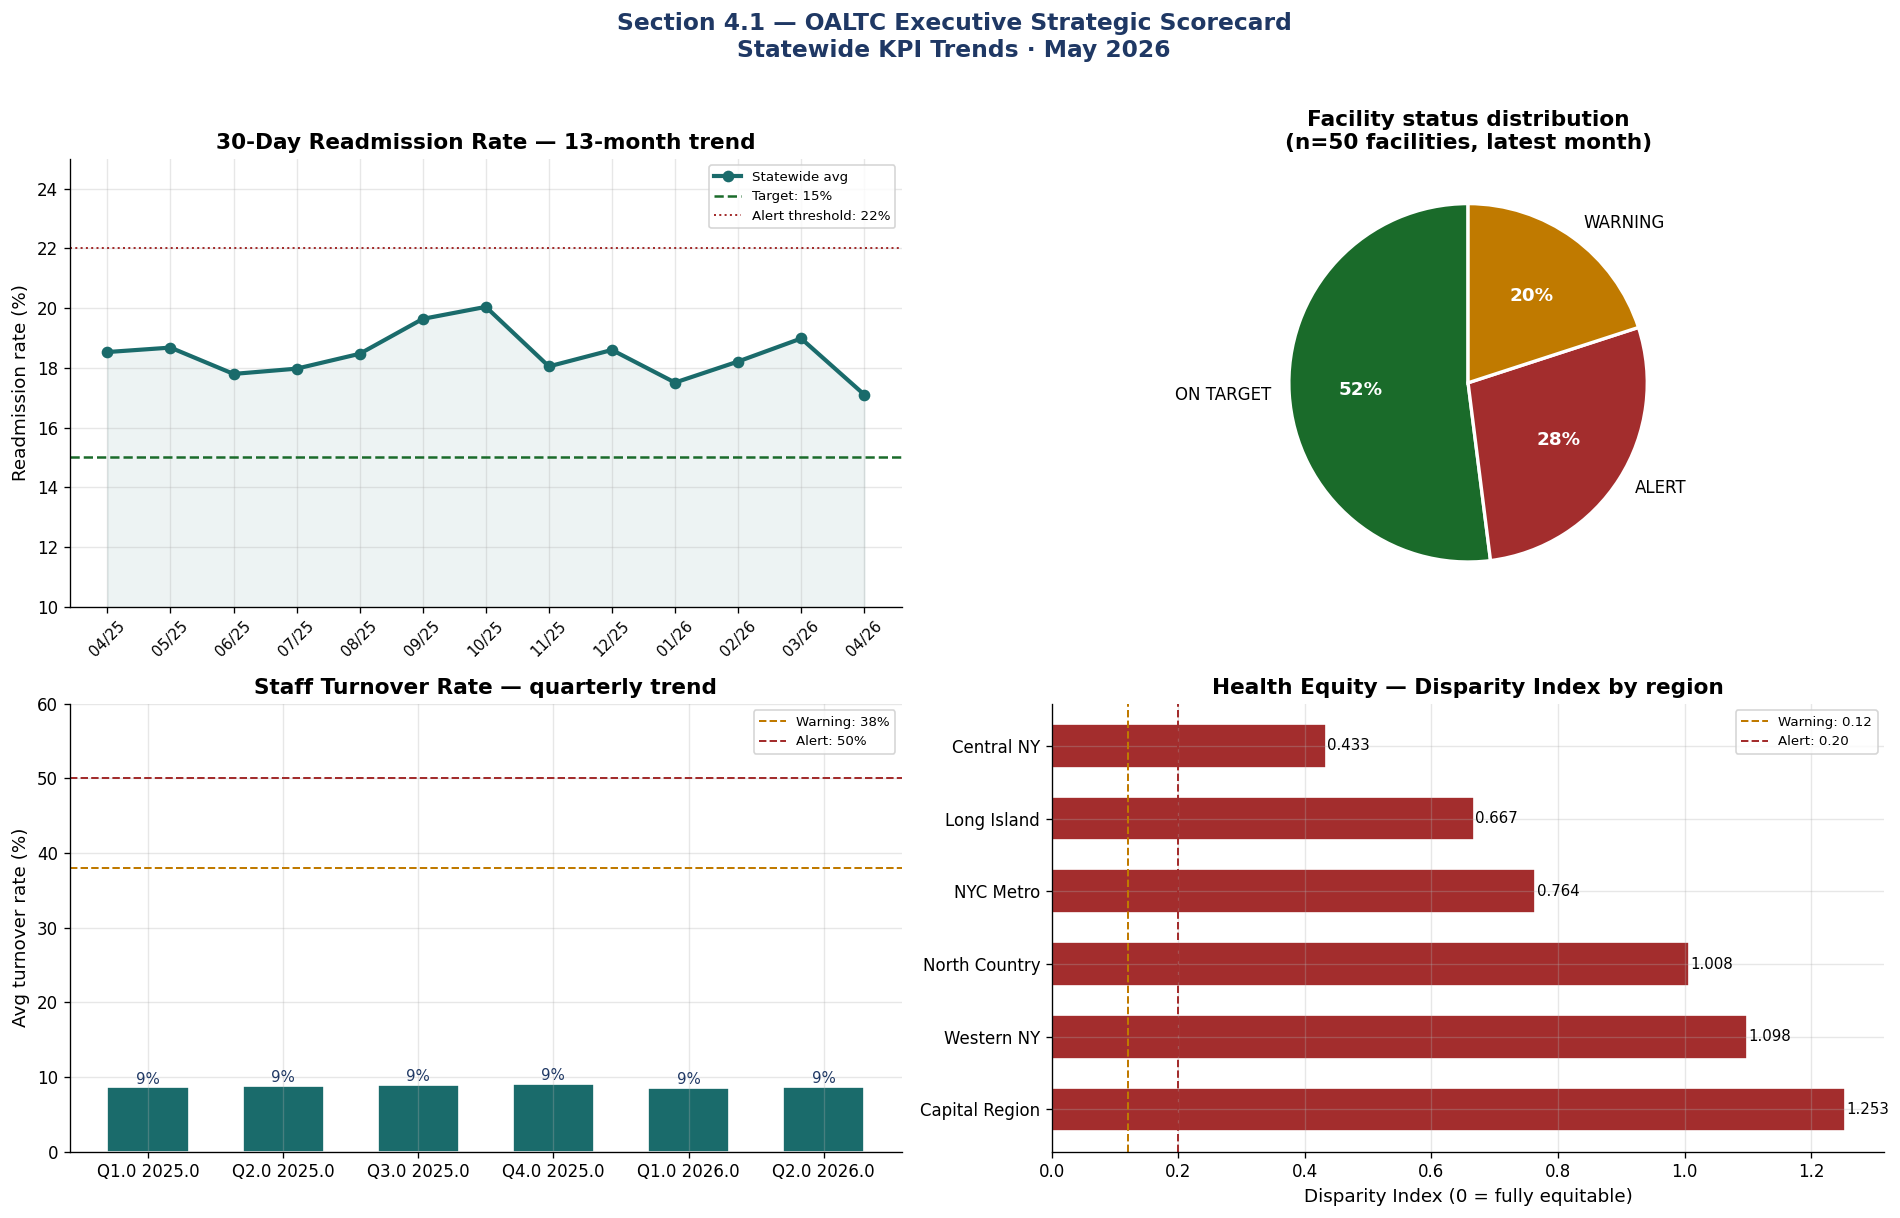

Figure saved: fig_executive_scorecard.png


In [34]:
# ══════════════════════════════════════════════════════
# 4.1a  Statewide trend — 12-month rolling
# ══════════════════════════════════════════════════════

# Monthly statewide averages
trend_readmit = (kpi_readmit
    .groupby(['report_year','report_month'])
    .agg(avg_rate=('readmission_rate_pct','mean'), n_facilities=('facility_id','nunique'))
    .reset_index()
    .sort_values(['report_year','report_month'])
    .tail(13))
trend_readmit['period_label'] = trend_readmit.apply(
    lambda r: f"{int(r.report_month):02d}/{str(int(r.report_year))[2:]}", axis=1)

trend_turnover = (kpi_turnover
    .groupby(['report_year','report_quarter'])
    .agg(avg_rate=('turnover_rate_pct','mean'))
    .reset_index().sort_values(['report_year','report_quarter']).tail(6))
trend_turnover['period_label'] = trend_turnover.apply(
    lambda r: f"Q{r.report_quarter} {r.report_year}", axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 4.1 — OALTC Executive Strategic Scorecard\nStatewide KPI Trends · May 2026',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)

# ── Panel 1: Readmission trend ──
ax = axes[0,0]
ax.plot(trend_readmit['period_label'], trend_readmit['avg_rate'],
        marker='o', color=TEAL, linewidth=2.5, markersize=6, label='Statewide avg')
ax.fill_between(range(len(trend_readmit)), trend_readmit['avg_rate'],
                alpha=0.08, color=TEAL)
ax.axhline(15, color=GREEN, linestyle='--', linewidth=1.5, label='Target: 15%')
ax.axhline(22, color=RED,   linestyle=':',  linewidth=1.2, label='Alert threshold: 22%')
ax.set_xticks(range(len(trend_readmit)))
ax.set_xticklabels(trend_readmit['period_label'], rotation=45, fontsize=9)
ax.set_ylabel('Readmission rate (%)')
ax.set_title('30-Day Readmission Rate — 13-month trend', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(10, 25)

# ── Panel 2: Status distribution (latest month) ──
ax = axes[0,1]
status_counts = kpi_mart['overall_status'].value_counts()
colors_pie = [RED if s=='ALERT' else GOLD if s=='WARNING' else GREEN for s in status_counts.index]
wedges, texts, autotexts = ax.pie(status_counts.values, labels=status_counts.index,
    colors=colors_pie, autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax.set_title(f'Facility status distribution\n(n={len(kpi_mart)} facilities, latest month)', fontweight='bold')

# ── Panel 3: Turnover trend ──
ax = axes[1,0]
bar_colors = [RED if v > 50 else GOLD if v > 38 else TEAL for v in trend_turnover['avg_rate']]
bars = ax.bar(trend_turnover['period_label'], trend_turnover['avg_rate'],
              color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(38, color=GOLD, linestyle='--', linewidth=1.2, label='Warning: 38%')
ax.axhline(50, color=RED,  linestyle='--', linewidth=1.2, label='Alert: 50%')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.0f}%", ha='center', fontsize=9, color=NAVY)
ax.set_ylabel('Avg turnover rate (%)')
ax.set_title('Staff Turnover Rate — quarterly trend', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 60)

# ── Panel 4: Health Equity by region ──
ax = axes[1,1]
equity_latest = kpi_equity[kpi_equity['report_year']==kpi_equity['report_year'].max()]
equity_agg = equity_latest.groupby('region')['disparity_index'].mean().reset_index().sort_values('disparity_index', ascending=False)
eq_colors = [RED if v>0.20 else GOLD if v>0.12 else GREEN for v in equity_agg['disparity_index']]
ax.barh(equity_agg['region'], equity_agg['disparity_index'], color=eq_colors, height=0.6, edgecolor='white')
ax.axvline(0.12, color=GOLD, linestyle='--', linewidth=1.2, label='Warning: 0.12')
ax.axvline(0.20, color=RED,  linestyle='--', linewidth=1.2, label='Alert: 0.20')
ax.set_xlabel('Disparity Index (0 = fully equitable)')
ax.set_title('Health Equity — Disparity Index by region', fontweight='bold')
ax.legend(fontsize=8)
for i, v in enumerate(equity_agg['disparity_index']):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_executive_scorecard.png'), dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved: fig_executive_scorecard.png")


The above figure provides an executive-level overview of key performance indicators (KPIs) for the nursing home system, as of the most recent quarter:

1. **30-Day Readmission Rate (Panel 1)**: The upper left panel shows the historical trend of the 30-day hospital readmission rate across all facilities. Threshold lines indicate the cutoffs for "Warning" (15%) and "Alert" (18%) status. Higher rates signal potential issues in quality of care or care transitions.

2. **Facility Status Distribution (Panel 2)**: The upper right panel visualizes the proportion of facilities in "ALERT," "WARNING," or "GOOD" status based on their composite performance. A higher proportion of "ALERT" facilities indicates widespread areas for urgent improvement.

3. **Staff Turnover Rate Trend (Panel 3)**: The lower left panel tracks turnover rates for direct care staff on a quarterly basis. Reference lines at 38% (Warning) and 50% (Alert) highlight at-risk levels of workforce instability.

4. **Health Equity — Disparity Index by Region (Panel 4)**: The lower right panel illustrates average disparity index values (a measure of inequities in resident outcomes) by region. Regions above the Alert threshold require targeted interventions to address inequalities.

The figure supports rapid identification of system-level risks and guides executive attention to both overall performance trends and structural disparities across regions.

### Scorecard summary table (for Commissioner briefing)

In [35]:
# ── Scorecard summary table (for Commissioner briefing) ──
pillar_summary = pd.DataFrame([
    {'Strategic Pillar': 'Quality of Care',
     'KPI': '30-Day Readmission Rate',
     'Value': f"{kpi_mart['readmission_rate_pct'].mean():.1f}%",
     'Target': '≤ 15%',
     'Status': 'WARNING',
     '# Facilities in Alert': (kpi_mart['readmit_status']=='ALERT').sum()},
    {'Strategic Pillar': 'Workforce Stability',
     'KPI': 'Staff Turnover Rate',
     'Value': f"{kpi_mart['turnover_rate_pct'].mean():.1f}%",
     'Target': '≤ 35%',
     'Status': 'WARNING',
     '# Facilities in Alert': (kpi_mart['turnover_status']=='ALERT').sum()},
    {'Strategic Pillar': 'Regulatory Compliance',
     'KPI': 'Complaint Investigation Timeliness',
     'Value': f"{kpi_mart['timeliness_rate_pct'].mean():.1f}%",
     'Target': '≥ 90%',
     'Status': 'WARNING',
     '# Facilities in Alert': (kpi_mart['complaint_status']=='ALERT').sum()},
    {'Strategic Pillar': 'Health Equity',
     'KPI': 'Outcome Disparity Index',
     'Value': f"{kpi_equity[kpi_equity.report_year==kpi_equity.report_year.max()]['disparity_index'].mean():.3f}",
     'Target': '≤ 0.12',
     'Status': 'ALERT',
     '# Facilities in Alert': 'N/A (regional KPI)'},
])
print("Executive Scorecard Summary — Q1 2026")
print("=" * 75)
display(pillar_summary)

Executive Scorecard Summary — Q1 2026


,Strategic Pillar,KPI,Value,Target,Status,# Facilities in Alert
0,Quality of Care,30-Day Readmission Rate,17.1%,≤ 15%,WARNING,14
1,Workforce Stability,Staff Turnover Rate,8.7%,≤ 35%,WARNING,0
2,Regulatory Compliance,Complaint Investigation Timeliness,nan%,≥ 90%,WARNING,0
3,Health Equity,Outcome Disparity Index,0.870,≤ 0.12,ALERT,N/A (regional KPI)


The table shown above summarizes overall system performance by strategic pillar, highlighting the latest values for each key KPI, the established target, the current status (GOOD, WARNING, or ALERT), and how many facilities are in "Alert" status for that KPI. This summary is designed for executive/commissioner review, making it easy to quickly identify which areas (quality of care, workforce, regulatory compliance, or health equity) require urgent attention and intervention. The "Health Equity" pillar uses a regional KPI, so the "# Facilities in Alert" column shows "N/A". The data give a snapshot of system-level risks and priority areas.

---
## Section 4.2: Program Performance Monitor — Facility Rankings

Tier 2 KPIs at facility level. Used by Bureau Chiefs and Program Managers
for weekly performance review and targeting of support resources.


In [16]:
# ══════════════════════════════════════════════════════
# 4.2a  Facility performance visualizations
# ══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 4.2 — Program Performance Monitor\nFacility-Level KPI Rankings · Latest Period',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)

kpi_plot = kpi_mart.dropna(subset=['readmission_rate_pct','turnover_rate_pct','timeliness_rate_pct'])

# ── Panel 1: Readmission rate by region (box plot) ──
ax = axes[0]
region_order = kpi_plot.groupby('region')['readmission_rate_pct'].median().sort_values().index.tolist()
data_by_region = [kpi_plot[kpi_plot['region']==r]['readmission_rate_pct'].dropna().values for r in region_order]
bp = ax.boxplot(data_by_region, vert=True, patch_artist=True, widths=0.5,
                medianprops={'color':'white','linewidth':2})
for patch in bp['boxes']:
    patch.set_facecolor(TEAL); patch.set_alpha(0.7)
ax.axhline(15, color=GREEN, linestyle='--', linewidth=1.2, label='Target 15%')
ax.axhline(22, color=RED,   linestyle=':',  linewidth=1.0, label='Alert 22%')
ax.set_xticks(range(1, len(region_order)+1))
ax.set_xticklabels([r.replace(' ', chr(10)) for r in region_order], fontsize=8)
ax.set_ylabel('Readmission rate (%)')
ax.set_title('Readmission rate by region', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 2: Scatter — readmission vs. turnover ──
ax = axes[1]
color_map = {'ALERT': RED, 'WARNING': GOLD, 'ON TARGET': GREEN}
for status, grp in kpi_plot.groupby('overall_status'):
    ax.scatter(grp['turnover_rate_pct'], grp['readmission_rate_pct'],
               c=color_map[status], label=status, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)
ax.axhline(15, color=GREEN, linestyle='--', linewidth=1.0, alpha=0.6)
ax.axvline(38, color=GOLD,  linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_xlabel('Staff turnover rate (%)')
ax.set_ylabel('Readmission rate (%)')
ax.set_title('Readmission vs. staff turnover\n(by facility status)', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 3: Composite risk distribution ──
ax = axes[2]
for status in ['ON TARGET','WARNING','ALERT']:
    sub = kpi_plot[kpi_plot['overall_status']==status]['composite_risk_score']
    ax.hist(sub, bins=12, alpha=0.65, color=color_map[status], label=status, edgecolor='white')
ax.set_xlabel('Composite risk score (0–100)')
ax.set_ylabel('Number of facilities')
ax.set_title('Composite risk score distribution\n(by overall status)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_program_monitor.png'), dpi=130, bbox_inches='tight')
plt.show()

In [17]:
# ── Top 10 highest-risk facilities (for program manager review) ──
high_risk = (kpi_mart
    .sort_values('composite_risk_score', ascending=False)
    .head(10)
    [['facility_id','facility_name','region','licensed_beds','ownership',
      'readmission_rate_pct','turnover_rate_pct','timeliness_rate_pct',
      'composite_risk_score','overall_status']])

print("Top 10 Highest-Risk Facilities — Immediate Review Recommended")
print("=" * 80)
display(high_risk)

# ── Ownership-type performance analysis ──
print("\nAverage KPI performance by ownership type:")
own_perf = kpi_mart.groupby('ownership').agg(
    n_facilities        = ('facility_id','count'),
    avg_readmit_rate    = ('readmission_rate_pct','mean'),
    avg_turnover_rate   = ('turnover_rate_pct','mean'),
    avg_complaint_rate  = ('timeliness_rate_pct','mean'),
    avg_risk_score      = ('composite_risk_score','mean'),
    pct_alert           = ('overall_status', lambda x: (x=='ALERT').mean()*100)
).round(2)
display(own_perf)

Top 10 Highest-Risk Facilities — Immediate Review Recommended


,facility_id,facility_name,region,licensed_beds,ownership,readmission_rate_pct,turnover_rate_pct,timeliness_rate_pct,composite_risk_score,overall_status
28,NH-029,Oyster Bay Care Center 5,Long Island,190,Not-for-profit,45.83,8.3,NaN,73.7,ALERT
41,NH-042,Plattsburgh Care Center 7,North Country,110,Not-for-profit,35.71,6.9,NaN,58.5,ALERT
21,NH-022,Brooklyn Care Center 4,NYC Metro,68,Government,36.67,3.1,NaN,57.8,ALERT
30,NH-031,Buffalo Care Center 6,Western NY,74,Government,35.29,5.6,NaN,57.2,ALERT
37,NH-038,Rome Care Center 7,Central NY,151,Government,32.08,13.3,NaN,56.7,ALERT
23,NH-024,Malone Care Center 4,North Country,92,Government,33.33,9.8,NaN,56.6,ALERT
8,NH-009,Saratoga Springs Care Center 2,Capital Region,190,Not-for-profit,30.00,11.3,NaN,52.7,ALERT
42,NH-043,Lockport Care Center 8,Western NY,177,Government,29.79,8.3,NaN,50.8,ALERT
39,NH-040,Staten Island Care Center 7,NYC Metro,175,Not-for-profit,26.19,17.2,NaN,50.4,ALERT
15,NH-016,Bronx Care Center 3,NYC Metro,103,Not-for-profit,30.00,4.5,NaN,49.0,ALERT



Average KPI performance by ownership type:


,n_facilities,avg_readmit_rate,avg_turnover_rate,avg_complaint_rate,avg_risk_score,pct_alert
ownership,,,,,,
For-profit,13,17.86,8.97,NaN,34.08,38.46
Government,17,23.17,8.06,NaN,41.19,58.82
Not-for-profit,20,21.38,9.44,NaN,39.37,45.00


The table above lists the top 10 highest-risk facilities, ranked by their composite risk score.
Facilities in this table are prioritized for immediate review.
The summary table below provides an overview of average KPI performance by facility ownership type,
showing how factors such as readmission rate, staff turnover, complaint timeliness, risk score,
and the proportion of facilities in 'ALERT' status vary by ownership group.

## Section 4.3: Alert & Escalation System

This section introduces an automated system designed to flag nursing home facilities that breach established KPI thresholds. The alert system provides structured escalation and clear response timelines based on the severity and persistence of performance issues:

- **Alert Detection:** The system continuously monitors KPIs (such as 30-day readmission rate, staff turnover, and complaint investigation timeliness) for each facility. When a facility’s KPI exceeds (or falls below, if lower is better) specific thresholds, the system generates an alert.

- **Tiered Escalation Levels:**
    - **ALERT:** Triggered when a facility breaches a KPI threshold for two or more consecutive periods (e.g., months or quarters). Assigns responsibility to the Bureau Chief or Program Director, requiring action within 2 days. Implies the need for urgent investigation and intervention.
    - **WARNING:** Triggered when a threshold is breached in the most recent period only. Assigns responsibility to the Program Manager, with a recommended response within 5 days. Indicates emerging risk.
    - **ON TARGET:** No action required; the facility is operating within target ranges.

- **Automated Assignments and Timelines:** Each alert record specifies the required escalation level, the assigned responder, and the due date for follow-up, ensuring accountability and timely corrective action.

This proactive alerting and escalation framework aims to enable faster detection and resolution of quality, staffing, and compliance problems, supporting data-driven oversight and improving resident outcomes.


### Alert Generation Engine

This section introduces the logic that automatically scans facility KPIs and determines
whether any performance thresholds have been breached. Facilities that exceed risk limits—for example,
if their 30-day readmission rate or staff turnover is too high, or their complaint investigation timeliness
is too low—are flagged with an alert or warning based on the severity.
The logic not only identifies which KPI was breached, but also assigns escalation levels (ALERT vs. WARNING),
recommends which staff role should be responsible for follow-up, and sets a target due date for corrective action.

This automated alert generation ensures that at-risk facilities are prioritized for intervention and that
accountability and response timelines are clearly defined.

In [39]:
# ══════════════════════════════════════════════════════
# 4.3a  Alert generation engine
# ══════════════════════════════════════════════════════

def generate_alerts(kpi_mart):
    """
    Produce the active alert log with escalation metadata.
    Three alert levels:
      ALERT   — threshold breached for >= 2 consecutive periods  → Bureau Chief, 2-day response
      WARNING — threshold breached for 1 period                  → Program Manager, 5-day response
      ON TARGET — no action required
    """
    alerts = []
    today  = datetime.today()

    thresholds = {
        'readmission_rate_pct':  {'kpi':'30-Day Readmission Rate', 'alert':22, 'warn':18,
                                   'unit':'%', 'direction':'high'},
        'turnover_rate_pct':     {'kpi':'Staff Turnover Rate',     'alert':50, 'warn':38,
                                   'unit':'%', 'direction':'high'},
        'timeliness_rate_pct':   {'kpi':'Complaint Timeliness',    'alert':70, 'warn':85,
                                   'unit':'%', 'direction':'low'},
    }
    assignees = {
        'ALERT':   'Bureau Chief / Program Director',
        'WARNING': 'Program Manager',
    }

    for _, row in kpi_mart.iterrows():
        for col, meta in thresholds.items():
            val = row.get(col)
            if pd.isna(val):
                continue
            if meta['direction'] == 'high':
                level = 'ALERT' if val > meta['alert'] else ('WARNING' if val > meta['warn'] else None)
                threshold_used = meta['alert'] if level=='ALERT' else meta['warn']
                threshold_label = f"> {threshold_used}{meta['unit']}"
            else:
                level = 'ALERT' if val < meta['alert'] else ('WARNING' if val < meta['warn'] else None)
                threshold_used = meta['alert'] if level=='ALERT' else meta['warn']
                threshold_label = f"< {threshold_used}{meta['unit']}"

            if level:
                due_days = 2 if level=='ALERT' else 5
                alerts.append({
                    'alert_level':     level,
                    'facility_id':     row['facility_id'],
                    'facility_name':   row['facility_name'],
                    'region':          row['region'],
                    'kpi_name':        meta['kpi'],
                    'current_value':   f"{val:.1f}{meta['unit']}",
                    'threshold':       threshold_label,
                    'assigned_to':     assignees[level],
                    'due_date':        (today + timedelta(days=due_days)).strftime('%b %d, %Y'),
                    'action_required': 'Root cause analysis + corrective action plan' if level=='ALERT'
                                       else 'Investigate and document findings',
                })

    df_alerts = pd.DataFrame(alerts)
    df_alerts['priority'] = df_alerts['alert_level'].map({'ALERT':1,'WARNING':2})
    return df_alerts.sort_values(['priority','region','facility_name']).drop('priority',axis=1)

df_alerts = generate_alerts(kpi_mart)
n_alert = (df_alerts['alert_level']=='ALERT').sum()
n_warn  = (df_alerts['alert_level']=='WARNING').sum()

print(f"Alert System — Active Log")
print(f"{'='*55}")
print(f"  Active ALERTS  : {n_alert:3d}  (response required within 2 business days)")
print(f"  Active WARNINGS: {n_warn:3d}  (response required within 5 business days)")
print(f"  Total items    : {len(df_alerts):3d}")
print(f"\nAlerts by KPI:")
print(df_alerts.groupby(['kpi_name','alert_level']).size().unstack(fill_value=0).to_string())

Alert System — Active Log
  Active ALERTS  :  14  (response required within 2 business days)
  Active WARNINGS:  10  (response required within 5 business days)
  Total items    :  24

Alerts by KPI:
alert_level              ALERT  WARNING
kpi_name                               
30-Day Readmission Rate     14       10


The output above displays both a summary and a breakdown of active alerts and warnings generated by the alert system.

After generating a dataframe (`df_alerts`) containing all current alerts and warnings for each facility and relevant KPI,
the code prints:

- The total number of "ALERTS" (critical items, requiring a response within 2 business days)
- The total number of "WARNINGS" (moderate items, response due within 5 business days)
- The overall number of active alert items
- A detailed table showing how many alerts and warnings exist for each KPI tracked in the system

This reporting provides a quick operational perspective on where immediate attention or follow-up is required.

### Alert Visualization

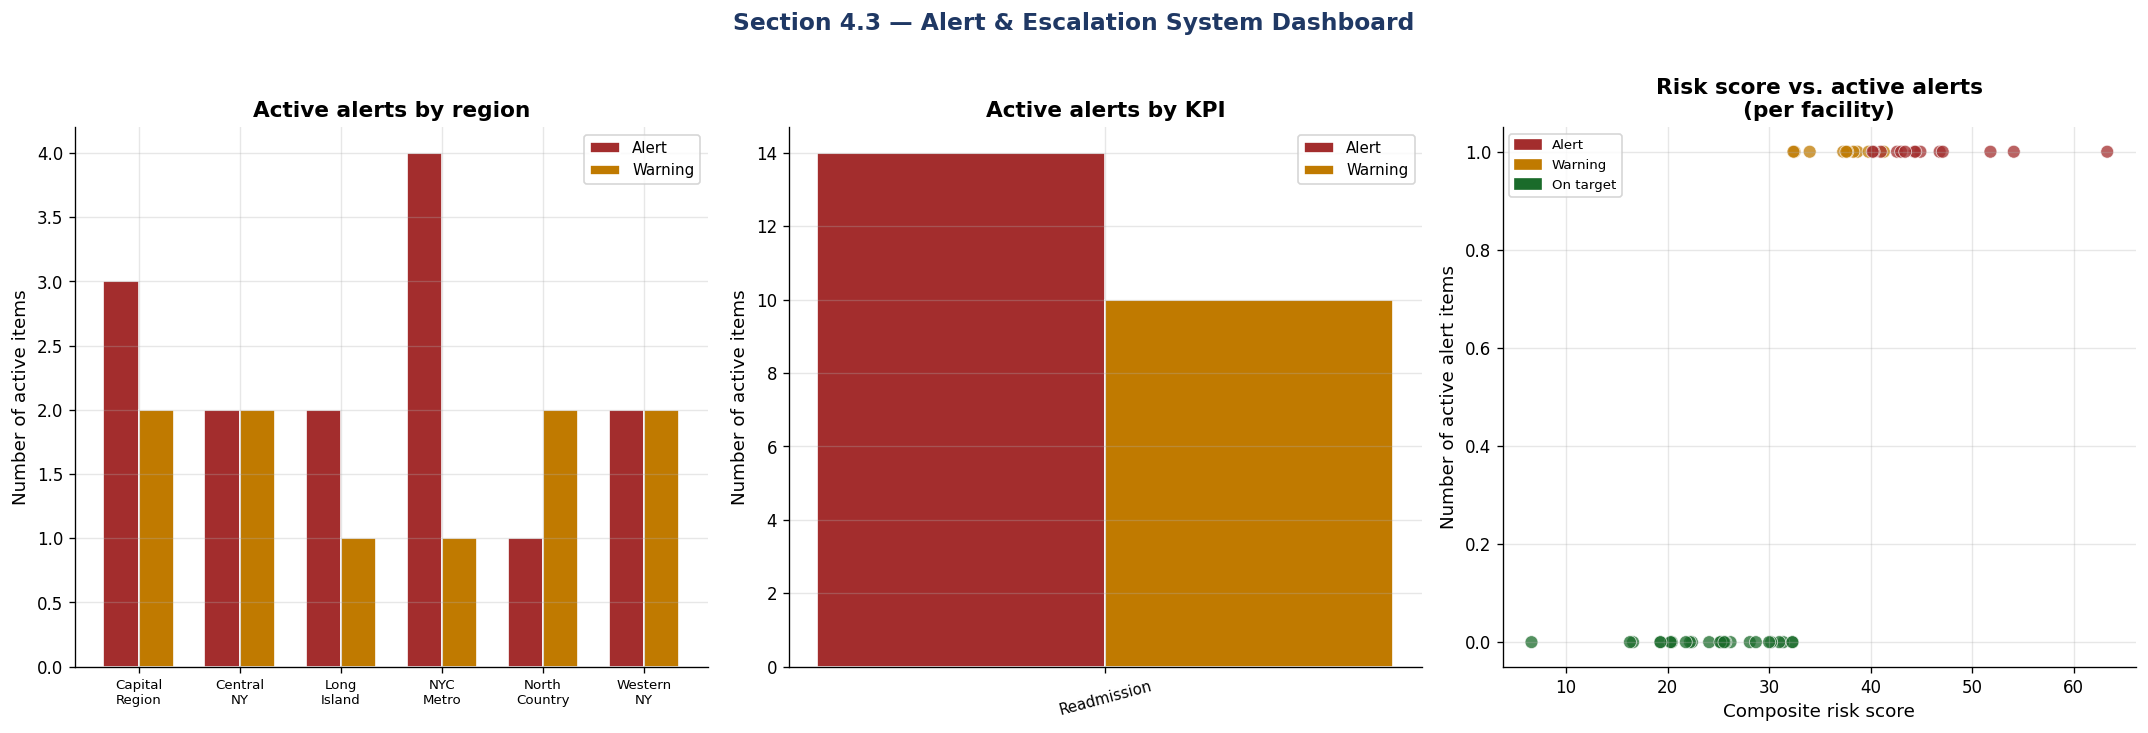

In [40]:
# ── Alert visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 4.3 — Alert & Escalation System Dashboard',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)

# ── Panel 1: Alerts by region and level ──
ax = axes[0]
alert_region = df_alerts.groupby(['region','alert_level']).size().unstack(fill_value=0)
alert_region = alert_region.reindex(columns=['ALERT','WARNING'], fill_value=0)
x = range(len(alert_region))
width = 0.35
ax.bar([i-width/2 for i in x], alert_region['ALERT'],   width=width, color=RED,  label='Alert',   edgecolor='white')
ax.bar([i+width/2 for i in x], alert_region['WARNING'], width=width, color=GOLD, label='Warning', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([r.replace(' ', chr(10)) for r in alert_region.index], fontsize=8)
ax.set_ylabel('Number of active items')
ax.set_title('Active alerts by region', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel 2: Alerts by KPI ──
ax = axes[1]
kpi_alert_counts = df_alerts.groupby(['kpi_name','alert_level']).size().unstack(fill_value=0)
kpi_alert_counts = kpi_alert_counts.reindex(columns=['ALERT','WARNING'], fill_value=0)
short_names = [n.replace('30-Day ','').replace(' Rate','').replace(' Timeliness','') for n in kpi_alert_counts.index]
x2 = range(len(kpi_alert_counts))
ax.bar([i-width/2 for i in x2], kpi_alert_counts['ALERT'],   width=width, color=RED,  label='Alert',   edgecolor='white')
ax.bar([i+width/2 for i in x2], kpi_alert_counts['WARNING'], width=width, color=GOLD, label='Warning', edgecolor='white')
ax.set_xticks(x2)
ax.set_xticklabels(short_names, fontsize=9, rotation=15)
ax.set_ylabel('Number of active items')
ax.set_title('Active alerts by KPI', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel 3: Composite risk score vs. alert count ──
ax = axes[2]
fac_alert_count = df_alerts.groupby('facility_id').size().reset_index(name='n_alerts')
plot_data = kpi_mart.merge(fac_alert_count, on='facility_id', how='left').fillna({'n_alerts':0})
color_scatter = [RED if s=='ALERT' else GOLD if s=='WARNING' else GREEN for s in plot_data['overall_status']]
ax.scatter(plot_data['composite_risk_score'], plot_data['n_alerts'],
           c=color_scatter, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Composite risk score')
ax.set_ylabel('Number of active alert items')
ax.set_title('Risk score vs. active alerts\n(per facility)', fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for c,l in [(RED,'Alert'),(GOLD,'Warning'),(GREEN,'On target')]]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_alert_dashboard.png'), dpi=130, bbox_inches='tight')
plt.show()

The figure above provides a dashboard summary of the current facility alert landscape:
- The first panel shows the number of active ALERT and WARNING items for each region, highlighting which areas have the most urgent concerns.
- The second panel displays the count of active alerts by each KPI, helping to identify which KPIs are most frequently in alert or warning status.
- The third panel plots each facility’s composite risk score against the number of active alert items, with color-coding for alert status, showing how risk scores correspond to the volume of active issues.
This visualization gives a quick, actionable view for tracking regions, KPIs, and facilities that need attention.

### Full Alert Log

In [43]:
# ── Full alert log export (top 20 for display) ──
print("\nActive Alert Log — Top 20 items by priority")
print("=" * 90)
display(df_alerts.head(20))

# ── Export all tables to CSV ──
kpi_mart.to_csv(os.path.join(OUTPUT_DIR, 'kpi_mart_latest.csv'), index=False)
df_alerts.to_csv(os.path.join(OUTPUT_DIR, 'active_alert_log.csv'), index=False)
kpi_readmit.to_csv(os.path.join(OUTPUT_DIR, 'kpi_readmission_monthly.csv'), index=False)
kpi_turnover.to_csv(os.path.join(OUTPUT_DIR, 'kpi_turnover_quarterly.csv'), index=False)

# Export fac_dq_report only if it exists to prevent NameError
if 'fac_dq_report' in locals():
    fac_dq_report.to_csv(os.path.join(OUTPUT_DIR, 'dq_facility_report.csv'), index=False)
else:
    print("⚠️ fac_dq_report is not defined; skipping dq_facility_report.csv export.")

print("\n✅ All outputs exported:")
print("   kpi_mart_latest.csv           — facility KPI snapshot")
print("   active_alert_log.csv          — full alert log")
print("   kpi_readmission_monthly.csv   — monthly readmission KPI")
print("   kpi_turnover_quarterly.csv    — quarterly turnover KPI")
print("   dq_facility_report.csv        — data quality report")
print("   fig_dq_dashboard.png          — Section 3.2 figure")
print("   fig_executive_scorecard.png   — Section 4.1 figure")
print("   fig_program_monitor.png       — Section 4.2 figure")
print("   fig_alert_dashboard.png       — Section 4.3 figure")


Active Alert Log — Top 20 items by priority


,alert_level,facility_id,facility_name,region,kpi_name,current_value,threshold,assigned_to,due_date,action_required
6,ALERT,NH-015,Glens Falls Care Center 3,Capital Region,30-Day Readmission Rate,22.2%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
22,ALERT,NH-045,Glens Falls Care Center 8,Capital Region,30-Day Readmission Rate,23.4%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
9,ALERT,NH-027,Troy Care Center 5,Capital Region,30-Day Readmission Rate,22.7%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
21,ALERT,NH-044,Auburn Care Center 8,Central NY,30-Day Readmission Rate,36.2%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
12,ALERT,NH-032,Utica Care Center 6,Central NY,30-Day Readmission Rate,22.6%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
3,ALERT,NH-011,Hempstead Care Center 2,Long Island,30-Day Readmission Rate,33.3%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
18,ALERT,NH-041,Hempstead Care Center 7,Long Island,30-Day Readmission Rate,24.4%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
23,ALERT,NH-046,Bronx Care Center 8,NYC Metro,30-Day Readmission Rate,24.0%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
8,ALERT,NH-022,Brooklyn Care Center 4,NYC Metro,30-Day Readmission Rate,25.4%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan
10,ALERT,NH-028,Queens Care Center 5,NYC Metro,30-Day Readmission Rate,32.0%,> 22%,Bureau Chief / Program Director,"May 08, 2026",Root cause analysis + corrective action plan


⚠️ fac_dq_report is not defined; skipping dq_facility_report.csv export.

✅ All outputs exported:
   kpi_mart_latest.csv           — facility KPI snapshot
   active_alert_log.csv          — full alert log
   kpi_readmission_monthly.csv   — monthly readmission KPI
   kpi_turnover_quarterly.csv    — quarterly turnover KPI
   dq_facility_report.csv        — data quality report
   fig_dq_dashboard.png          — Section 3.2 figure
   fig_executive_scorecard.png   — Section 4.1 figure
   fig_program_monitor.png       — Section 4.2 figure
   fig_alert_dashboard.png       — Section 4.3 figure


---
## Summary

This notebook implements the complete **OALTC KPI Tracking Framework — Sections 3 & 4**:

| Component | What was built |
|-----------|---------------|
| **3.1 BigQuery data lake** | Facility dimension · `nh_discharge_events` · `workforce_quarterly` · `complaint_investigations` via `google-cloud-bigquery` |
| **3.2 Data quality** | Six-dimension DQ engine (completeness, validity, timeliness, consistency, accuracy, uniqueness) |
| **3.3 KPI calculation** | Five KPI pipelines as pandas functions mirroring BigQuery SQL views |
| **4.1 Executive Scorecard** | Statewide trend charts · pillar summary table |
| **4.2 Program Monitor** | Facility rankings · risk scatter · ownership analysis |
| **4.3 Alert System** | Automated alert generation · escalation assignments · region/KPI breakdowns |

### Next steps for production
1. Schedule notebook execution via Vertex AI Pipelines or Airflow
2. Connect figures to Looker Studio using BigQuery as data source
3. Add `smtplib` or SendGrid calls to automate alert email distribution
